# Results & Figures 

**Purpose:** Read saved results from upstream notebooks and generate all figures and tables for the manuscript. No model fitting or heavy computation — only loading, formatting, and plotting.

**Data sources:**
- `data/processed/component_results.h5` — per-component projections, observations, posteriors, blended forecast
- `data/processed/slr_processed_data.h5` — historical observations, kinematics
- `data/processed/bayesian_ratestate_posterior.h5` — semi-empirical model (posterior, projections, sensitivity)
- `data/processed/manuscript_headline_stats.json` — precomputed headline statistics
- `data/processed/ipcc_distributions.h5` — IPCC AR6 samples for comparison

**Sections mirror the manuscript:**
- §0 Setup & data loading
- §1 Headline numbers (Abstract & key claims)
- §2 Figure 1 — Observations
- §3 Figure 2 — 
- §4 Figure 3 — 
- §5 Figure 4 — 
- §8 Supplementary tables & figures
- 

---
## §0 Setup & data loading

In [1]:
import json
import sys
from pathlib import Path

import h5py
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl

# Project imports
sys.path.insert(0, str(Path('.').resolve()))
from component_io import (
    load_all_projections, load_component, list_components,
    PROJ_YEARS, PROJ_SSPS, DEFAULT_H5_PATH, N_SAMPLES, BASELINE_YEAR,
)
from slr_forecast.config import (
    HAMLINGTON_RATE, HAMLINGTON_RATE_UNC,
    HAMLINGTON_ACCEL, HAMLINGTON_ACCEL_UNC,
    HAMLINGTON_T_REF, PROCESSED_DATA_DIR, 
    FIG_DIR, SSPS, IPCC_CONFIDENCE, Z_90,
)
from slr_forecast import M_TO_MM, M_TO_CM
from component_projections import (
    read_ipcc_component_nc, ipcc_extract, read_ismip6_regional,
)

# Paths
H5_OBS = PROCESSED_DATA_DIR / 'slr_processed_data.h5'
H5_COMP = DEFAULT_H5_PATH
H5_IPCC = PROCESSED_DATA_DIR / 'ipcc_distributions.h5'
H5_RATESTATE = PROCESSED_DATA_DIR / 'bayesian_ratestate_posterior.h5'
JSON_HEADLINE = PROCESSED_DATA_DIR / 'manuscript_headline_stats.json'
JSON_GREENLAND_CT = PROCESSED_DATA_DIR / 'greenland_ct_estimate.json'

RAW_DIR = Path('..') / 'data' / 'raw'
CONF_BASE = str(RAW_DIR / 'ipcc_ar6' / 'slr' / 'ar6' / 'global' / 'confidence_output_files')
ISMIP6_BASE = str(RAW_DIR / 'ice_sheets' / 'ismip6' / 'ComputedScalarsPaper')
SSP_TO_CODE = {
    'SSP1-2.6': 'ssp126', 'SSP2-4.5': 'ssp245',
    'SSP3-7.0': 'ssp370', 'SSP5-8.5': 'ssp585',
}

# Plotting defaults
sys.path.insert(0, str(Path('.').resolve() / 'arete_mpl'))
import arete_mpl
arete_mpl.use('poster')
plt.rcParams.update({
    'figure.dpi': 150,
    'font.size': 10,
    'axes.labelsize': 11,
    'legend.fontsize': 9,
})

# Conversion (M_TO_MM, M_TO_CM imported from slr_forecast)

# SSP colors (consistent across figures)
SSP_COLORS = {
    'SSP1-2.6': '#2166ac',
    'SSP2-4.5': '#1b7837',
    'SSP3-7.0': '#e08214',
    'SSP5-8.5': '#b2182b',
}

# Policy-relevant SSPs (exclude SSP5-8.5 for headline stats)
POLICY_SSPS = ['SSP1-2.6', 'SSP2-4.5', 'SSP3-7.0']

# Components included in the forecast sum (EAIS excluded)
FORECAST_COMPONENTS = ['ocean', 'glacier', 'greenland', 'apeninsula', 'wais']

print(f'Baseline year: {BASELINE_YEAR}')
print(f'Ensemble size: {N_SAMPLES}')
print(f'Projection years: {PROJ_YEARS[0]:.0f}–{PROJ_YEARS[-1]:.0f}')

Baseline year: 2000.0
Ensemble size: 2000
Projection years: 1950–2150


In [2]:
# Load all component projections
proj_years, all_proj = load_all_projections()
list_components()

# Index for year 2100
i2100 = np.searchsorted(proj_years, 2100)
i2050 = np.searchsorted(proj_years, 2050)

print(f'\nIndex for 2100: {i2100} (year = {proj_years[i2100]:.0f})')
print(f'Index for 2050: {i2050} (year = {proj_years[i2050]:.0f})')

File: /Users/minchew/Dropbox/Documents/Research/SLR/forecasting/global_simple_v1/slr_forecast/data/processed/component_results.h5
  Baseline year: 2005.0
  N samples: 2000
  Proj years: 1950–2150

  apeninsula
    model: linear_dols
    SSPs: SSP1-2.6, SSP2-4.5, SSP3-7.0, SSP5-8.5
    full samples: True
    saved: 2026-05-03T03:41:14.622514+00:00
  blended
    model: unknown
    SSPs: 
    full samples: False
    saved: 2026-05-03 04:12:08.357438+00:00
  eais
    model: trend_only
    SSPs: SSP1-2.6, SSP2-4.5, SSP3-7.0, SSP5-8.5
    full samples: True
    saved: 2026-05-03T03:40:02.484635+00:00
  glacier
    model: linear_dols
    SSPs: SSP1-2.6, SSP2-4.5, SSP3-7.0, SSP5-8.5
    full samples: True
    saved: 2026-05-03T03:38:04.203167+00:00
  greenland
    model: smb_literature_plus_discharge_delay
    SSPs: SSP1-2.6, SSP2-4.5, SSP3-7.0, SSP5-8.5
    full samples: True
    saved: 2026-05-03T03:39:17.494740+00:00
  ocean
    model: twolayer_noaa
    SSPs: SSP1-2.6, SSP2-4.5, SSP3-7.0, S

In [3]:
# Load observational data
with pd.HDFStore(H5_OBS, mode='r') as store:
    df_frederikse = store['raw/df_frederikse']
    df_nasa = store['raw/df_nasa_gmsl']
    df_berkeley = store['raw/df_berkeley']
    # Kinematics (rates)
    kin_keys = [k for k in store.keys() if 'kinematics' in k]
    print('Kinematics keys:', kin_keys)

# Helper: extract year range from DatetimeIndex or float index
def _year_range(idx):
    if hasattr(idx, 'year'):
        return f'{idx[0].year}–{idx[-1].year}'
    return f'{idx[0]:.1f}–{idx[-1]:.1f}'

print(f'Frederikse: {_year_range(df_frederikse.index)}')
print(f'NASA altimetry: {_year_range(df_nasa.index)}')
print(f'Berkeley Earth: {_year_range(df_berkeley.index)}')
print(f'Frederikse columns: {list(df_frederikse.columns[:6])}...')

Kinematics keys: ['/kinematics/gmst/berkeley', '/kinematics/gmsl/dangendorf', '/kinematics/gmsl/frederikse', '/kinematics/gmsl/frederikse_thermodynamic_gmsl', '/kinematics/gmsl/frederikse_thermodynamic_sum', '/kinematics/gmsl/horwath', '/kinematics/gmsl/ipcc', '/kinematics/gmsl/nasa']
Frederikse: 1900–2018
NASA altimetry: 1993–2025
Berkeley Earth: 1850–2024
Frederikse columns: ['year', 'gmsl_lower', 'gmsl', 'gmsl_upper', 'sum_contributors_lower', 'sum_contributors']...


In [4]:
# Load rate-and-state results from consolidated HDF5
with h5py.File(H5_RATESTATE, 'r') as hf:
    _rs_coeffs = hf['calibration/coefficients'][:]  # [a, b, c, d] in m/yr
    _rs_r2 = float(hf['calibration'].attrs['r_squared'])

    # Build ratestate dict matching the old JSON structure for downstream cells
    ratestate = {
        'calibration': {
            'r_squared': _rs_r2,
            'coefficients_mm_yr': {
                'dalpha_dT': float(_rs_coeffs[0] * M_TO_MM),
                'alpha0':    float(_rs_coeffs[1] * M_TO_MM),
                'trend':     float(_rs_coeffs[2] * M_TO_MM),
                'd_diseq':   float(_rs_coeffs[3] * M_TO_MM),
            },
        },
        'projections_at_2100_mm': {},
    }

    # Projections at 2100
    for ssp in ['SSP1-2.6', 'SSP2-4.5', 'SSP3-7.0', 'SSP5-8.5']:
        sg = hf[f'projections/{ssp}']
        ratestate['projections_at_2100_mm'][ssp] = {
            'median': float(sg.attrs['median_at_2100_m'] * M_TO_MM),
            'p5':     float(sg.attrs['p5_at_2100_m'] * M_TO_MM),
            'p95':    float(sg.attrs['p95_at_2100_m'] * M_TO_MM),
        }

# Load headline stats
with open(JSON_HEADLINE) as f:
    headline = json.load(f)

print(f'Rate-and-state R²: {ratestate["calibration"]["r_squared"]:.4f}')
print('Rate-and-state projections at 2100 (mm):')
for ssp, vals in ratestate['projections_at_2100_mm'].items():
    print(f"  {ssp}: median={vals['median']:.0f}, 90% CI=[{vals['p5']:.0f}, {vals['p95']:.0f}]")

Rate-and-state R²: 0.9680
Rate-and-state projections at 2100 (mm):
  SSP1-2.6: median=780, 90% CI=[650, 906]
  SSP2-4.5: median=1304, 90% CI=[1044, 1557]
  SSP3-7.0: median=1999, 90% CI=[1558, 2420]
  SSP5-8.5: median=2772, 90% CI=[2129, 3388]


In [5]:
# --- Load blended forecast samples ---
# Exported by component_forecast.ipynb
blended = {}
with h5py.File(H5_COMP, 'r') as hf:
    if 'blended' in hf:
        bg = hf['blended']
        blended_years = bg['forecast_years'][:]
        blended_w = bg['sigmoid_weight'][:]
        blended_meta = dict(bg.attrs)
        for ssp in PROJ_SSPS:
            if ssp in bg:
                sg = bg[ssp]
                blended[ssp] = {
                    'samples': sg['samples'][:],
                    'median': sg['median'][:],
                    'p5': sg['p5'][:],
                    'p17': sg['p17'][:],
                    'p83': sg['p83'][:],
                    'p95': sg['p95'][:],
                }
        print(f'Blended forecast loaded: {sorted(blended.keys())}')
        print(f'  Years: {blended_years[0]:.1f}–{blended_years[-1]:.0f}')
        print(f'  Sigmoid center: {blended_meta.get("t_center", "?")}')
        print(f'  Components: {list(blended_meta.get("components_summed", []))}')
    else:
        print('WARNING: blended group not found in component_results.h5')
        print('  Run component_forecast.ipynb to export blended samples.')

# Index for year 2100 in blended forecast
i2100_b = np.argmin(np.abs(blended_years - 2100))
i2050_b = np.argmin(np.abs(blended_years - 2050))
print(f'  Blended index for 2100: {i2100_b} (year = {blended_years[i2100_b]:.0f})')

# --- Pre-industrial offset (from blended HDF5 attrs, established upstream) ---
# This is SLR from pre-industrial (~1850-1900) to the 2000 baseline.
# Value set in component_forecast.ipynb from Frederikse et al. (2020) + literature.
PREINDUSTRIAL_OFFSET_M = float(blended_meta['preindustrial_to_baseline_m'])
print(f'\nPre-industrial offset (from blended attrs): {PREINDUSTRIAL_OFFSET_M} m')

# --- Load IPCC total medians from NetCDF (Gap 2) ---
IPCC_MEDIANS_MM = {}
for ssp, code in SSP_TO_CODE.items():
    data = read_ipcc_component_nc(CONF_BASE, IPCC_CONFIDENCE, code, 'total')
    if data is not None:
        ie = ipcc_extract(data)
        idx_2100 = np.argmin(np.abs(ie['years'] - 2100))
        IPCC_MEDIANS_MM[ssp] = ie['q50'][idx_2100]  # mm

print(f'\nIPCC AR6 total medians at 2100 (mm, from NetCDF):')
for ssp, val in IPCC_MEDIANS_MM.items():
    print(f'  {ssp}: {val:.0f} mm')

# --- Load rate-and-state posterior and sensitivity curves (Gaps 5, 7) ---
rs_posterior = {}
if H5_RATESTATE.exists():
    with h5py.File(H5_RATESTATE, 'r') as hf:
        # Posterior samples
        rs_posterior['coefficients'] = hf['posterior/coefficients'][:]
        rs_posterior['tau'] = hf['posterior/tau'][:]

        # Rate-vs-T curve
        rs_posterior['T_grid'] = hf['rate_vs_T/T_grid_C'][:]
        rs_posterior['rate_median'] = hf['rate_vs_T/rate_median_mm_yr'][:]
        rs_posterior['rate_p5'] = hf['rate_vs_T/rate_p5_mm_yr'][:]
        rs_posterior['rate_p95'] = hf['rate_vs_T/rate_p95_mm_yr'][:]

        # Sensitivity curve
        rs_posterior['sens_median'] = hf['sensitivity_vs_T/sensitivity_median_mm_yr_C'][:]
        rs_posterior['sens_p5'] = hf['sensitivity_vs_T/sensitivity_p5_mm_yr_C'][:]
        rs_posterior['sens_p95'] = hf['sensitivity_vs_T/sensitivity_p95_mm_yr_C'][:]

        # Record-averaged sensitivity
        rs_posterior['avg_sens_median'] = float(
            hf['record_averaged_sensitivity/median_mm_yr_C'][()])
        rs_posterior['avg_sens_p5'] = float(
            hf['record_averaged_sensitivity/p5_mm_yr_C'][()])
        rs_posterior['avg_sens_p95'] = float(
            hf['record_averaged_sensitivity/p95_mm_yr_C'][()])

    print(f'\nRate-and-state posterior loaded:')
    print(f'  Posterior samples: {rs_posterior["coefficients"].shape}')
    print(f'  Record-averaged sensitivity: {rs_posterior["avg_sens_median"]:.1f} '
          f'[{rs_posterior["avg_sens_p5"]:.1f}, {rs_posterior["avg_sens_p95"]:.1f}] '
          f'mm/yr/°C')
    print(f'  (cf. Rahmstorf 2007: 3.4 mm/yr/°C)')
else:
    print('\nWARNING: bayesian_ratestate_posterior.h5 not found.')
    print('  Run bayesian_ratestate.ipynb to export posterior samples.')

Blended forecast loaded: ['SSP1-2.6', 'SSP2-4.5', 'SSP3-7.0', 'SSP5-8.5']
  Years: 2026.0–2150
  Sigmoid center: 2035.0
  Components: ['ocean', 'glacier', 'greenland', 'apeninsula', 'wais', 'tws']
  Blended index for 2100: 74 (year = 2100)

Pre-industrial offset (from blended attrs): 0.19 m

IPCC AR6 total medians at 2100 (mm, from NetCDF):
  SSP1-2.6: 437 mm
  SSP2-4.5: 556 mm
  SSP3-7.0: 678 mm
  SSP5-8.5: 766 mm

Rate-and-state posterior loaded:
  Posterior samples: (2000, 4)
  Record-averaged sensitivity: 3.5 [3.0, 4.2] mm/yr/°C
  (cf. Rahmstorf 2007: 3.4 mm/yr/°C)


In [6]:
# --- Component sum at 2100 (21st-century contributions, relative to baseline) ---
# Diagnostic: raw component sums (no blending, no TWS) vs IPCC
print('=== Component-sum projections at 2100 (mm, rel. to 2000 baseline) ===')
print('NOTE: These are raw component sums (no blending, no TWS). See blended forecast below.')
print(f'{"SSP":<12} {"Median":>8} {"P5":>8} {"P95":>8} {"IPCC med":>10} {"Ratio":>8}')
print('-' * 60)

for ssp in PROJ_SSPS:
    total_samples = np.zeros(N_SAMPLES)
    for comp in FORECAST_COMPONENTS:
        total_samples += all_proj[comp][ssp]['samples'][:, i2100]
    
    med = np.median(total_samples) * M_TO_MM
    p5 = np.percentile(total_samples, 5) * M_TO_MM
    p95 = np.percentile(total_samples, 95) * M_TO_MM
    ipcc = IPCC_MEDIANS_MM.get(ssp, np.nan)
    ratio = med / ipcc if not np.isnan(ipcc) else np.nan
    
    print(f'{ssp:<12} {med:8.0f} {p5:8.0f} {p95:8.0f} {ipcc:10.0f} {ratio:8.2f}x')

=== Component-sum projections at 2100 (mm, rel. to 2000 baseline) ===
NOTE: These are raw component sums (no blending, no TWS). See blended forecast below.
SSP            Median       P5      P95   IPCC med    Ratio
------------------------------------------------------------
SSP1-2.6          763      421     1923        437     1.75x
SSP2-4.5          937      588     2093        556     1.68x
SSP3-7.0         1135      780     2299        678     1.67x
SSP5-8.5         1337      968     2497        766     1.75x


In [7]:
# --- Blended forecast at 2100 (21st-century contributions, rel. to 2000 baseline) ---
# These are the authoritative manuscript values.
print('=== Blended forecast at 2100 (cm, rel. to 2000 baseline) ===')
print()

for ssp in PROJ_SSPS:
    s = blended[ssp]['samples'][:, i2100_b]
    med = np.median(s) * M_TO_CM
    p5 = np.percentile(s, 5) * M_TO_CM
    p95 = np.percentile(s, 95) * M_TO_CM
    print(f'{ssp}: {med:.0f} cm [{p5:.0f}–{p95:.0f} cm]')

# Cross-check against headline stats
print()
print('Headline stats (manuscript_headline_stats.json):')
for ssp in PROJ_SSPS:
    hs = headline['scenarios'][ssp]['2100']
    print(f'  {ssp}: {hs["median_mm_rel_baseline"]/10:.0f} cm '
          f'[{hs["p5_mm_rel_baseline"]/10:.0f}–{hs["p95_mm_rel_baseline"]/10:.0f} cm]')

=== Blended forecast at 2100 (cm, rel. to 2000 baseline) ===

SSP1-2.6: 78 cm [44–192 cm]
SSP2-4.5: 95 cm [61–208 cm]
SSP3-7.0: 115 cm [80–229 cm]
SSP5-8.5: 134 cm [98–248 cm]

Headline stats (manuscript_headline_stats.json):
  SSP1-2.6: 78 cm [44–192 cm]
  SSP2-4.5: 95 cm [61–208 cm]
  SSP3-7.0: 115 cm [80–229 cm]
  SSP5-8.5: 134 cm [98–248 cm]


In [8]:
# --- Pre-industrial values (for abstract) ---
# Uses blended samples + authoritative pre-industrial offset
print(f'=== Abstract values (m, rel. to pre-industrial, offset = {PREINDUSTRIAL_OFFSET_M} m) ===')
print()

for ssp in POLICY_SSPS:
    s = blended[ssp]['samples'][:, i2100_b]
    s_pi = s + PREINDUSTRIAL_OFFSET_M
    
    med = np.median(s_pi)
    p5 = np.percentile(s_pi, 5)
    p95 = np.percentile(s_pi, 95)
    
    print(f'{ssp}: median = {med:.2f} m [{p5:.2f}–{p95:.2f} m]')

# Cross-check against headline stats
print()
print('Headline stats:')
for ssp in POLICY_SSPS:
    hs = headline['scenarios'][ssp]['2100']
    print(f'  {ssp}: {hs["median_m_rel_preindustrial"]:.2f} m '
          f'[{hs["p5_m_rel_preindustrial"]:.2f}–{hs["p95_m_rel_preindustrial"]:.2f} m]')
print(f'  Range: {headline["preindustrial_median_range_m"]} m')

=== Abstract values (m, rel. to pre-industrial, offset = 0.19 m) ===

SSP1-2.6: median = 0.97 m [0.63–2.11 m]
SSP2-4.5: median = 1.14 m [0.80–2.27 m]
SSP3-7.0: median = 1.34 m [0.99–2.48 m]

Headline stats:
  SSP1-2.6: 0.97 m [0.63–2.11 m]
  SSP2-4.5: 1.14 m [0.80–2.27 m]
  SSP3-7.0: 1.34 m [0.99–2.48 m]
  Range: [0.97, 1.34] m


In [9]:
# --- Exceedance probabilities ---
# Uses blended samples + authoritative pre-industrial offset
print('=== P(exceed 1 m relative to pre-industrial) ===')
print()

exceed_probs = {}
for ssp in POLICY_SSPS:
    s = blended[ssp]['samples'][:, i2100_b]
    s_pi = s + PREINDUSTRIAL_OFFSET_M
    p_exceed = np.mean(s_pi > 1.0) * 100
    exceed_probs[ssp] = p_exceed
    print(f'{ssp}: P(>1 m) = {p_exceed:.1f}%')

avg_exceed = np.mean(list(exceed_probs.values()))
print(f'\nScenario-averaged: {avg_exceed:.1f}%')

# Cross-check against headline stats
print()
print('Headline stats:')
for ssp in POLICY_SSPS:
    hs = headline['scenarios'][ssp]['2100']
    print(f'  {ssp}: P(>1 m) = {hs["P_exceed_1.0m_preindustrial"]:.1f}%')
print(f'  Avg: {headline["P_exceed_1m_avg_policy_ssps"]:.1f}%')

=== P(exceed 1 m relative to pre-industrial) ===

SSP1-2.6: P(>1 m) = 46.3%
SSP2-4.5: P(>1 m) = 73.5%
SSP3-7.0: P(>1 m) = 94.5%

Scenario-averaged: 71.4%

Headline stats:
  SSP1-2.6: P(>1 m) = 46.3%
  SSP2-4.5: P(>1 m) = 73.5%
  SSP3-7.0: P(>1 m) = 94.5%
  Avg: 71.4%


In [10]:
# --- IPCC comparison ratios (blended forecast) ---
print('=== Our median / IPCC median (blended forecast) ===')
print()

for ssp in PROJ_SSPS:
    s = blended[ssp]['samples'][:, i2100_b]
    med_mm = np.median(s) * M_TO_MM
    ipcc = IPCC_MEDIANS_MM[ssp]
    ratio = med_mm / ipcc
    pct_above = (ratio - 1) * 100
    
    print(f'{ssp}: {med_mm:.0f} / {ipcc:.0f} = {ratio:.2f}x ({pct_above:.0f}% above IPCC)')

# Cross-check against headline stats
print()
print('Headline stats:')
for ssp in PROJ_SSPS:
    if ssp in headline.get('ipcc_comparison', {}):
        ic = headline['ipcc_comparison'][ssp]
        print(f'  {ssp}: {ic["pct_above_ipcc"]:.0f}% above')
print(f'  Policy SSP range: {headline.get("ipcc_pct_above_range", "N/A")}%')

=== Our median / IPCC median (blended forecast) ===

SSP1-2.6: 782 / 437 = 1.79x (79% above IPCC)
SSP2-4.5: 946 / 556 = 1.70x (70% above IPCC)
SSP3-7.0: 1152 / 678 = 1.70x (70% above IPCC)
SSP5-8.5: 1340 / 766 = 1.75x (75% above IPCC)

Headline stats:
  SSP1-2.6: 79% above
  SSP2-4.5: 70% above
  SSP3-7.0: 70% above
  SSP5-8.5: 75% above
  Policy SSP range: [70, 79]%


In [11]:
# --- Variance decomposition (blended forecast) ---
print('=== Variance decomposition (law of total variance across policy SSPs) ===')
print()

# Collect 2100 blended samples per SSP
ssp_samples = {}
for ssp in POLICY_SSPS:
    ssp_samples[ssp] = blended[ssp]['samples'][:, i2100_b]

# Within-scenario variance (average of per-SSP variances)
var_within = np.mean([np.var(s) for s in ssp_samples.values()])

# Between-scenario variance (variance of per-SSP means)
var_between = np.var([np.mean(s) for s in ssp_samples.values()])

var_total = var_within + var_between
pct_within = var_within / var_total * 100
pct_between = var_between / var_total * 100

print(f'Within-scenario:  {pct_within:.1f}% of total variance')
print(f'Between-scenario: {pct_between:.1f}% of total variance')

# SSP2-4.5 90% range
ssp245 = ssp_samples['SSP2-4.5']
range_90 = (np.percentile(ssp245, 95) - np.percentile(ssp245, 5)) * M_TO_CM
median_spread = (np.median(ssp_samples['SSP3-7.0']) - np.median(ssp_samples['SSP1-2.6'])) * M_TO_CM
print(f'\nSSP2-4.5 90% range: {range_90:.0f} cm')
print(f'Cross-scenario median spread: {median_spread:.0f} cm')
print(f'Ratio: {range_90 / median_spread:.0f}x')

# Cross-check against headline stats
vd = headline['variance_decomposition']
print(f'\nHeadline stats:')
print(f'  Within: {vd["pct_within_scenario"]:.1f}%, Between: {vd["pct_between_scenario"]:.1f}%')
print(f'  90% range SSP2-4.5: {headline["within_scenario_90pct_range_mm_SSP245"]/10:.0f} cm')
print(f'  Cross-scenario spread: {headline["cross_scenario_median_spread_mm"]/10:.0f} cm')
print(f'  Ratio: {headline["ratio_within_to_across"]:.0f}x')

=== Variance decomposition (law of total variance across policy SSPs) ===

Within-scenario:  92.6% of total variance
Between-scenario: 7.4% of total variance

SSP2-4.5 90% range: 147 cm
Cross-scenario median spread: 37 cm
Ratio: 4x

Headline stats:
  Within: 92.8%, Between: 7.2%
  90% range SSP2-4.5: 147 cm
  Cross-scenario spread: 37 cm
  Ratio: 4x


In [49]:
# --- Rate doubling analysis (manuscript opening) ---
# Two parallel analyses, each self-consistent for hindcast and forecast:
#   1. Hamlington/Frederikse kinematic rates (observations only).
#   2. Rate-and-state model driven by observed + projected temperature.

import h5py
from slr_forecast.config import (
    HAMLINGTON_RATE, HAMLINGTON_RATE_UNC,
    HAMLINGTON_ACCEL, HAMLINGTON_ACCEL_UNC,
    HAMLINGTON_T_REF,
)

# Current epoch: end of satellite altimetry record (not T_REF midpoint)
T_NOW = 2024.0

# ── Shared data ──
with pd.HDFStore(H5_OBS, 'r') as store:
    _df_berk      = store['/harmonized/df_berkeley_h']
    _df_ssp245    = store['/projections/temp/SSP2_4_5']

# Annual-mean GMST + SSP2-4.5 extension for forecast warming
_ann = _df_berk[['temperature']].resample('YS').mean()
_ann['year'] = _ann.index.year + 0.5

# Splice Berkeley obs with SSP2-4.5 projections
_ssp_yr = _df_ssp245['decimal_year'].values
_ssp_T  = _df_ssp245['temperature'].values.copy()
_ssp_T_sigma = _df_ssp245['temperature_sigma'].values.copy()
_ov_idx = np.argmin(np.abs(_ann['year'].values - _ssp_yr[0]))
_cal_offset = _ssp_T[0] - _ann['temperature'].iloc[_ov_idx]
_ssp_T -= _cal_offset

_berk_t = _ann['year'].values
_berk_T = _ann['temperature'].values
_mask_hist = _berk_t < _ssp_yr[0]
_n_hist = _mask_hist.sum()
_full_t = np.concatenate([_berk_t[_mask_hist], _ssp_yr])
_full_T = np.concatenate([_berk_T[_mask_hist], _ssp_T])
_full_T_sigma = np.concatenate([
    np.zeros(_n_hist),
    _ssp_T_sigma,
])
_full_T_anom = _full_T - np.interp(BASELINE_YEAR, _full_t, _full_T)

# ── Quadratic temperature fit (1970+) for warming calculations ──
# Captures accelerating warming; avoids interannual noise (El Nino etc.)
_mask_1970 = _ann['year'].values >= 1970
_t_fit = _ann['year'].values[_mask_1970]
_T_fit = _ann['temperature'].values[_mask_1970]
_T_trend_coeffs = np.polyfit(_t_fit, _T_fit, 2)
# Evaluate on full time axis, rebased to BASELINE_YEAR
_T_trend = np.polyval(_T_trend_coeffs, _full_t)
_T_trend_anom = _T_trend - np.interp(BASELINE_YEAR, _full_t, _T_trend)
# Report equivalent linear rate and acceleration
_t_mid = 0.5 * (_t_fit[0] + _t_fit[-1])
_dTdt_mid = 2 * _T_trend_coeffs[0] * _t_mid + _T_trend_coeffs[1]
_d2Tdt2 = 2 * _T_trend_coeffs[0]
print(f"Quadratic T fit (1970-present): "
      f"rate at {_t_mid:.0f} = {_dTdt_mid:.4f} deg C/yr "
      f"({_dTdt_mid*10:.3f} deg C/decade), "
      f"accel = {_d2Tdt2:.5f} deg C/yr^2")

# Helpers
N_MC = 10_000

def _pct(arr, pcts=[5, 50, 95]):
    valid = arr[np.isfinite(arr)]
    return {f'p{p}': np.percentile(valid, p) for p in pcts}

def _fmt(arr, fmt='.0f'):
    s = _pct(arr)
    return f"{s['p50']:{fmt}} [{s['p5']:{fmt}}, {s['p95']:{fmt}}]"

def _find_crossing_backward(rate_2d, threshold_1d, t_array, t_max):
    """For each MC sample, search backward from t_max for last crossing."""
    n = rate_2d.shape[0]
    crossing = np.full(n, np.nan)
    i_max = np.searchsorted(t_array, t_max, side='right') - 1
    for k in range(n):
        below = np.where(rate_2d[k, :i_max + 1] <= threshold_1d[k])[0]
        if len(below) > 0:
            idx = below[-1]
            if idx < i_max:
                r_lo, r_hi = rate_2d[k, idx], rate_2d[k, idx + 1]
                if r_hi != r_lo:
                    frac = (threshold_1d[k] - r_lo) / (r_hi - r_lo)
                    crossing[k] = t_array[idx] + frac * (t_array[idx + 1] - t_array[idx])
                else:
                    crossing[k] = t_array[idx + 1]
    return crossing

def _find_crossing_forward(rate_2d, threshold_1d, t_array, t_min):
    """For each MC sample, search forward from t_min for first crossing."""
    n = rate_2d.shape[0]
    crossing = np.full(n, np.nan)
    i_min = np.searchsorted(t_array, t_min)
    for k in range(n):
        above = np.where(rate_2d[k, i_min:] >= threshold_1d[k])[0]
        if len(above) > 0:
            idx = above[0] + i_min
            if idx > 0:
                r_lo, r_hi = rate_2d[k, idx - 1], rate_2d[k, idx]
                if r_hi != r_lo:
                    frac = (threshold_1d[k] - r_lo) / (r_hi - r_lo)
                    crossing[k] = t_array[idx - 1] + frac * (t_array[idx] - t_array[idx - 1])
                else:
                    crossing[k] = t_array[idx]
    return crossing

def _warming_at(yr_arr, t_for_T, T_for_T):
    """Interpolate warming anomaly at given years.

    T_for_T: 1D (shared trajectory) or 2D (N_MC x n_t, per-sample).
    """
    if T_for_T.ndim == 1:
        return np.array([
            float(np.interp(yr, t_for_T, T_for_T)) if np.isfinite(yr) else np.nan
            for yr in yr_arr
        ])
    else:
        return np.array([
            float(np.interp(yr, t_for_T, T_for_T[k])) if np.isfinite(yr) else np.nan
            for k, yr in enumerate(yr_arr)
        ])

def _report_doublings(label, yr_quarter, yr_half, yr_full, yr_double,
                      t_for_T, T_for_T):
    """Print hindcast and forecast doubling results.

    yr_quarter, yr_half, yr_full: per-sample years when rate reached r/4, r/2, r.
    yr_double: per-sample years when rate reaches 2r (forecast), or None.
    """
    T_q = _warming_at(yr_quarter, t_for_T, T_for_T)
    T_h = _warming_at(yr_half, t_for_T, T_for_T)
    T_f = _warming_at(yr_full, t_for_T, T_for_T)

    dur_1st  = yr_half - yr_quarter
    warm_1st = T_h - T_q
    dur_2nd  = yr_full - yr_half
    warm_2nd = T_f - T_h

    print(f"\n{'=' * 60}")
    print(f"=== {label} ===")
    print(f"{'=' * 60}")

    print(f"\n  --- First doubling (r/4 -> r/2) ---")
    print(f"  Quarter-rate epoch: {_fmt(yr_quarter)}")
    print(f"  Half-rate epoch:    {_fmt(yr_half)}")
    print(f"  Duration:           {_fmt(dur_1st)} yr")
    print(f"  Warming:            {_fmt(warm_1st, '.2f')} deg C")

    print(f"\n  --- Second doubling (r/2 -> r) ---")
    print(f"  Half-rate epoch:    {_fmt(yr_half)}")
    print(f"  Full-rate epoch:    {_fmt(yr_full)}")
    print(f"  Duration:           {_fmt(dur_2nd)} yr")
    print(f"  Warming:            {_fmt(warm_2nd, '.2f')} deg C")

    if yr_double is not None:
        n_finite = np.isfinite(yr_double).sum()
        pct_ok = n_finite / len(yr_double) * 100

        print(f"\n  --- Next doubling (r -> 2r, forecast) ---")
        for target_yr in [2050, 2075, 2100]:
            p = np.nansum(yr_double <= target_yr) / len(yr_double) * 100
            print(f"  P(double by {target_yr}):  {p:.1f}%")

        if pct_ok >= 50:
            T_d = _warming_at(yr_double, t_for_T, T_for_T)
            dur_next = yr_double - yr_full
            warm_next = T_d - T_f
            print(f"  Year reached:  {_fmt(yr_double)} ({pct_ok:.0f}% of MC samples)")
            print(f"  Duration:      {_fmt(dur_next)} yr")
            print(f"  Warming:       {_fmt(warm_next, '.2f')} deg C")
        else:
            print(f"  ({pct_ok:.0f}% of MC samples reach 2r by {t_for_T[-1]:.0f})")
            if n_finite > 0:
                T_d = _warming_at(yr_double, t_for_T, T_for_T)
                dur_next = yr_double - yr_full
                warm_next = T_d - T_f
                print(f"  [Conditional on crossing: year {_fmt(yr_double)}, "
                      f"duration {_fmt(dur_next)} yr, "
                      f"warming {_fmt(warm_next, '.2f')} deg C]")

    print()
    print(f"  Summary: 1st doubling {_fmt(dur_1st)} yr / {_fmt(warm_1st, '.2f')} deg C")
    print(f"           2nd doubling {_fmt(dur_2nd)} yr / {_fmt(warm_2nd, '.2f')} deg C")


# =====================================================================
# 1. Hamlington / Dangendorf (constant-acceleration quadratic)
# =====================================================================
# Dangendorf et al. (2019) showed acceleration has been approximately
# constant since the 1960s and consistent with Hamlington et al. (2024).
# With constant acceleration a, rate(t) = r_now + a*(t - T_NOW), so
# all crossing times are analytical.
rng_hf = np.random.default_rng(42)

# MC: draw rate and acceleration
boot_rate_hf = rng_hf.normal(HAMLINGTON_RATE, HAMLINGTON_RATE_UNC / Z_90, N_MC)
boot_accel_hf = rng_hf.normal(HAMLINGTON_ACCEL, HAMLINGTON_ACCEL_UNC / Z_90, N_MC)

# Current rate at T_NOW
boot_rate_now_hf = boot_rate_hf + boot_accel_hf * (T_NOW - HAMLINGTON_T_REF)

# Analytical crossing times (constant acceleration):
#   rate(t) = r_now + a*(t - T_NOW)
#   r/4:  t = T_NOW - 3*r_now / (4*a)
#   r/2:  t = T_NOW - r_now / (2*a)
#   2r:   t = T_NOW + r_now / a
yr_full_hf    = np.full(N_MC, T_NOW)
yr_half_hf    = T_NOW - boot_rate_now_hf / (2 * boot_accel_hf)
yr_quarter_hf = T_NOW - 3 * boot_rate_now_hf / (4 * boot_accel_hf)

# Filter: require positive acceleration and physically plausible dates
_bad = boot_accel_hf <= 0
yr_half_hf[_bad] = np.nan
yr_quarter_hf[_bad] = np.nan

yr_next_hf = T_NOW + boot_rate_now_hf / boot_accel_hf
yr_next_hf[_bad] = np.nan
yr_next_hf[yr_next_hf < T_NOW] = np.nan
yr_next_hf[yr_next_hf > 2200] = np.nan

_report_doublings(
    "Hamlington / Dangendorf (constant-acceleration quadratic)",
    yr_quarter_hf, yr_half_hf, yr_full_hf, yr_next_hf,
    _full_t, _T_trend_anom,
)


# =====================================================================
# 2. Rate-and-state model
# =====================================================================
rng_rs = np.random.default_rng(99)

with h5py.File(str(PROCESSED_DATA_DIR / 'bayesian_ratestate_posterior.h5'), 'r') as f:
    _rs_coeffs = f['posterior/coefficients'][:] * M_TO_MM  # (n_post, 4)
    _rs_tau    = f['posterior/tau'][:]

def _solve_state_ode(T, t, tau):
    """Euler solve dS/dt = (T - S) / tau."""
    S = np.zeros_like(T)
    S[0] = T[0]
    for i in range(len(T) - 1):
        dt = t[i + 1] - t[i]
        S[i + 1] = S[i] + dt * (T[i] - S[i]) / tau
    return S

# Draw posterior samples
n_post = len(_rs_coeffs)
idx_draw = rng_rs.choice(n_post, N_MC, replace=True)
_a = _rs_coeffs[idx_draw, 0]
_b = _rs_coeffs[idx_draw, 1]
_c = _rs_coeffs[idx_draw, 2]
_d = _rs_coeffs[idx_draw, 3]
_tau = _rs_tau[idx_draw]

# Compute rate(t) for each MC sample
boot_rates_rs = np.zeros((N_MC, len(_full_t)))
for k in range(N_MC):
    T_k = _full_T.copy()
    T_k[_n_hist:] += rng_rs.normal(0, _full_T_sigma[_n_hist:])
    S_k = _solve_state_ode(T_k, _full_t, _tau[k])
    boot_rates_rs[k] = _a[k] * T_k**2 + _b[k] * T_k + _c[k] + _d[k] * (S_k - T_k)

# Current rate at T_NOW
i_now = np.argmin(np.abs(_full_t - T_NOW))
boot_rate_rs_now = boot_rates_rs[:, i_now]

# Hindcast: backward crossings from T_NOW
# yr_full is the evaluation epoch — the point that defines r
yr_full_rs    = np.full(N_MC, _full_t[i_now])
yr_half_rs    = _find_crossing_backward(boot_rates_rs, boot_rate_rs_now / 2, _full_t, T_NOW)
yr_quarter_rs = _find_crossing_backward(boot_rates_rs, boot_rate_rs_now / 4, _full_t, T_NOW)

# Forecast: forward crossing at 2 x r_now
yr_next_rs = _find_crossing_forward(boot_rates_rs, 2 * boot_rate_rs_now, _full_t, T_NOW)
yr_next_rs[yr_next_rs < T_NOW] = np.nan
yr_next_rs[yr_next_rs > 2200] = np.nan

_report_doublings(
    "Rate-and-state model (obs T -> SSP2-4.5)",
    yr_quarter_rs, yr_half_rs, yr_full_rs, yr_next_rs,
    _full_t, _T_trend_anom,
)

# =====================================================================
# Side-by-side comparison
# =====================================================================
print("\n" + "=" * 60)
print("=== Side-by-side comparison ===")
print("=" * 60)
print(f"{'':30s} {'Hamlington/Fred':>18s}   {'Rate-and-state':>18s}")
print(f"  Current rate (mm/yr):        {_fmt(boot_rate_now_hf, '.1f'):>18s}   {_fmt(boot_rate_rs_now, '.1f'):>18s}")
print(f"  1st doubling duration (yr):  {_fmt(yr_half_hf - yr_quarter_hf):>18s}   {_fmt(yr_half_rs - yr_quarter_rs):>18s}")
print(f"  2nd doubling duration (yr):  {_fmt(yr_full_hf - yr_half_hf):>18s}   {_fmt(yr_full_rs - yr_half_rs):>18s}")
for target_yr in [2050, 2075, 2100]:
    p_hf = np.nansum(yr_next_hf <= target_yr) / N_MC * 100
    p_rs = np.nansum(yr_next_rs <= target_yr) / N_MC * 100
    print(f"  P(double by {target_yr}):         {p_hf:>17.1f}%   {p_rs:>17.1f}%")


Quadratic T fit (1970-present): rate at 1998 = 0.0206 deg C/yr (0.206 deg C/decade), accel = 0.00022 deg C/yr^2

=== Hamlington / Dangendorf (constant-acceleration quadratic) ===

  --- First doubling (r/4 -> r/2) ---
  Quarter-rate epoch: 1982 [1911, 1995]
  Half-rate epoch:    1996 [1949, 2005]
  Duration:           14 [10, 38] yr
  Warming:            0.26 [0.19, 0.32] deg C

  --- Second doubling (r/2 -> r) ---
  Half-rate epoch:    1996 [1949, 2005]
  Full-rate epoch:    2024 [2024, 2024]
  Duration:           28 [19, 75] yr
  Warming:            0.66 [0.47, 1.29] deg C

  --- Next doubling (r -> 2r, forecast) ---
  P(double by 2050):  0.0%
  P(double by 2075):  36.8%
  P(double by 2100):  76.3%
  Year reached:  2079 [2062, 2140] (95% of MC samples)
  Duration:      55 [38, 116] yr
  Warming:       1.80 [1.17, 2.59] deg C

  Summary: 1st doubling 14 [10, 38] yr / 0.26 [0.19, 0.32] deg C
           2nd doubling 28 [19, 75] yr / 0.66 [0.47, 1.29] deg C

=== Rate-and-state model (obs

---
## §2 Figure 1 — Observations

Three stacked panels:
- **(a)** GMSL (Frederikse + NASA) and GMST (Berkeley Earth, 10-yr smooth) since 1900
- **(b)** GMSL rate and GMST (same smooth) on shared x-axis
- **(c)** GMSL rate vs GMST scatter: observations colored by time (viridis), rate-and-state model colored by instantaneous sensitivity α = dḢ/dT (magma)

In [ ]:
sc_time = kin_fred_time[mask_kin_fred]
sc_rate = kin_fred_rate[mask_kin_fred]
sc_rate_se = kin_fred_rate_se[mask_kin_fred]
sc_T = T_at_fred_rate

# ── Rate doubling visualization ──
# Find T at each threshold from LOWESS smooth of observed rate vs T,
# with bootstrap uncertainty from rate standard errors.
_order = np.argsort(sc_T)
_sc_T_sorted = sc_T[_order]
_sc_rate_sorted = sc_rate[_order]
_sc_rate_se_sorted = sc_rate_se[_order]

def _find_threshold_T(rate_smooth, T_sorted, thresh):
    """Find T where smoothed rate crosses thresh (last crossing)."""
    crossings = np.where(np.diff(np.sign(rate_smooth - thresh)))[0]
    if len(crossings) > 0:
        idx = crossings[-1]
        dr = rate_smooth[idx + 1] - rate_smooth[idx]
        if dr != 0:
            frac = (thresh - rate_smooth[idx]) / dr
            return T_sorted[idx] + frac * (T_sorted[idx + 1] - T_sorted[idx])
    return np.nan

_rate_vs_T_smooth = sm.nonparametric.lowess(
    _sc_rate_sorted, _sc_T_sorted, frac=0.3, return_sorted=False)

_doubling_thresholds = [1.0, 2.0, 4.0]
_T_at_threshold = {}
for _thresh in _doubling_thresholds:
    _T_at_threshold[_thresh] = _find_threshold_T(
        _rate_vs_T_smooth, _sc_T_sorted, _thresh)

# Bootstrap: perturb rates by SE, re-smooth, find crossings
_N_BOOT = 2000
_rng_boot = np.random.default_rng(123)
_T_boot = {th: np.full(_N_BOOT, np.nan) for th in _doubling_thresholds}
for _ib in range(_N_BOOT):
    _perturbed = _sc_rate_sorted + _rng_boot.normal(0, _sc_rate_se_sorted)
    _smooth_b = sm.nonparametric.lowess(
        _perturbed, _sc_T_sorted, frac=0.3, return_sorted=False)
    for _thresh in _doubling_thresholds:
        _T_boot[_thresh][_ib] = _find_threshold_T(_smooth_b, _sc_T_sorted, _thresh)

# Compute dT and its 1-sigma uncertainty for each doubling
_dT_boot_1 = _T_boot[2.0] - _T_boot[1.0]
_dT_boot_2 = _T_boot[4.0] - _T_boot[2.0]
_dT1_mean = np.nanmean(_dT_boot_1)
_dT1_std  = np.nanstd(_dT_boot_1)
_dT2_mean = np.nanmean(_dT_boot_2)
_dT2_std  = np.nanstd(_dT_boot_2)

# Convert T crossings to calendar years via LOWESS-smoothed GMST
_berk_yr = berk_annual.loc[berk_annual['temp_smooth'].notna(), 'year'].values
_berk_Ts = berk_annual.loc[berk_annual['temp_smooth'].notna(), 'temp_smooth'].values

def _T_to_year(T_val):
    """Interpolate GMST anomaly back to calendar year."""
    if np.isnan(T_val):
        return np.nan
    return float(np.interp(T_val, _berk_Ts, _berk_yr))

# Central epoch years
_yr_at_threshold = {th: _T_to_year(_T_at_threshold[th]) for th in _doubling_thresholds}

# Bootstrap epoch years
_yr_boot = {th: np.array([_T_to_year(t) for t in _T_boot[th]]) for th in _doubling_thresholds}
_yr_std = {th: np.nanstd(_yr_boot[th]) for th in _doubling_thresholds}

# Print for manuscript
print("Rate doubling epochs (for manuscript caption):")
for th in _doubling_thresholds:
    print(f"  Rate = {th:.0f} mm/yr: year = {_yr_at_threshold[th]:.0f} "
          f"+/- {_yr_std[th]:.0f}")
print(f"  1st doubling: {_yr_at_threshold[1.0]:.0f}--{_yr_at_threshold[2.0]:.0f} "
      f"({_yr_at_threshold[1.0] - _yr_std[1.0]:.0f}--{_yr_at_threshold[2.0] + _yr_std[2.0]:.0f}), "
      f"dT = {_dT1_mean:.2f} +/- {_dT1_std:.2f} deg C")
print(f"  2nd doubling: {_yr_at_threshold[2.0]:.0f}--{_yr_at_threshold[4.0]:.0f} "
      f"({_yr_at_threshold[2.0] - _yr_std[2.0]:.0f}--{_yr_at_threshold[4.0] + _yr_std[4.0]:.0f}), "
      f"dT = {_dT2_mean:.2f} +/- {_dT2_std:.2f} deg C")


  Rate = 1 mm/yr at T = -0.470 deg C
  Rate = 2 mm/yr at T = -0.153 deg C
  Rate = 4 mm/yr at T = 0.256 deg C
  1st doubling (1->2 mm/yr): dT = 0.339 +/- 0.039 deg C
  2nd doubling (2->4 mm/yr): dT = 0.411 +/- 0.027 deg C


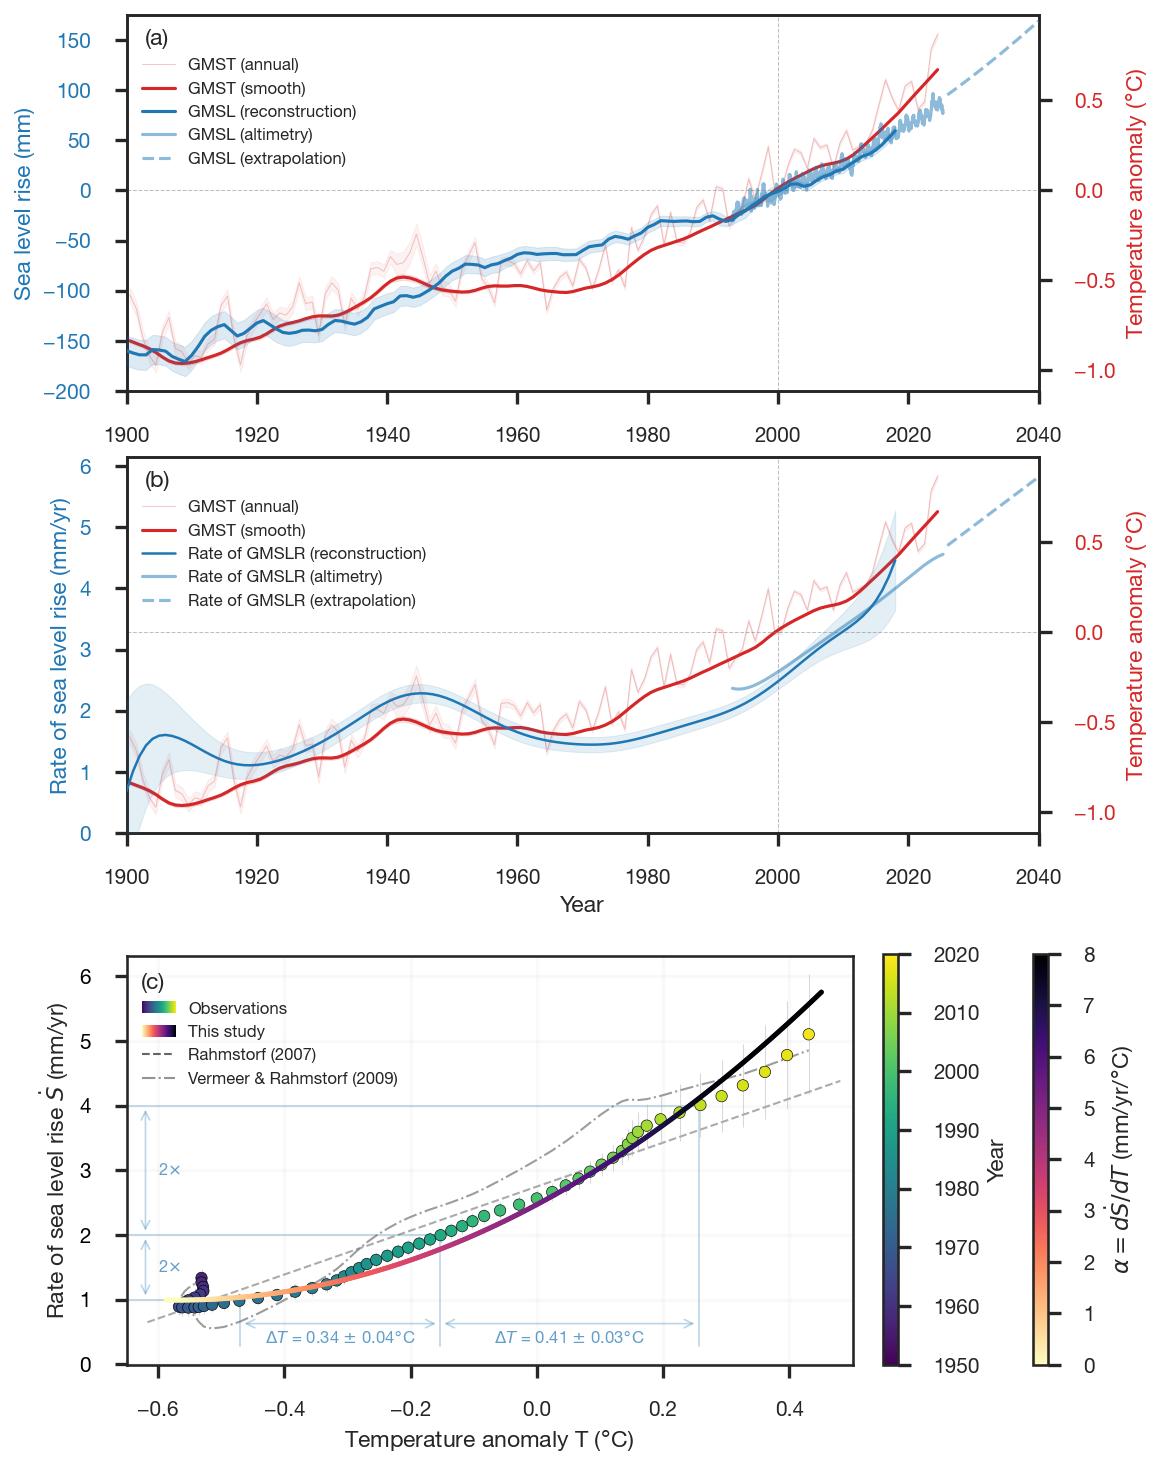

Figure 1 saved.


In [107]:
# ==================================================================
# Figure 1: Observations — GMSL level, GMSL rate + GMST, scatter
# ==================================================================
import matplotlib.gridspec as gridspec
from slr_forecast.config import SAT_ERA_START, Z_90

# ── Font sizes (adjust here) ──
FS_XLABEL  = 11
FS_YLABEL  = 11
FS_XTICK   = 10
FS_YTICK   = 10
FS_LEGEND  = 8
FS_PANEL   = 11   # (a), (b), (c) labels
FS_CBARLABEL = FS_YLABEL  # colorbar axis label
FS_CBARTICK  = FS_YTICK   # colorbar tick labels

# ── Legend positions (bbox_to_anchor, adjust to fine-tune) ──
LEG_BBOX_A = (0., 0.925)   # Panel A: None = auto, or e.g. (0.0, 1.0)
LEG_BBOX_B = LEG_BBOX_A    # Panel B
LEG_BBOX_C = LEG_BBOX_A    # Panel C

# ── Legend order (reorder by name; items not listed are appended) ──
LEG_ORDER_A = ['GMST (annual)', 'GMST (smooth)', 'GMSL (reconstruction)', 'GMSL (altimetry)', 'GMSL extrapolation']  # e.g. ['GMSL (5-yr smooth)', 'NASA altimetry', 'Quadratic extrapolation', f'GMST ({GMST_SMOOTH_YR}-yr smooth)']
LEG_ORDER_B = ['GMST (annual)', 'GMST (smooth)', 'GMSL rate (reconstruction)', 'GMSL rate (altimetry)', 'GMSL rate extrapolation']  # e.g. ['GMSL rate (Frederikse)', 'NASA altimetry rate', 'Quadratic extrapolation', f'GMST ({GMST_SMOOTH_YR}-yr smooth)']
LEG_ORDER_C = ['Observations', 'This study', 'Rahmstorf (2007)', 'Vermeer & Rahmstorf (2009)']

# ── Panels axis limits ──
XLIM_AB = (1900, 2040)  # shared x-axis for panels A and B
YLIM_SL = (-200, 175)  # GMSL in mm; symmetric
YLIM_SLR = (0,6.25)  

# ── Load harmonized data (meters, rebased to BASELINE_YEAR) ──
with pd.HDFStore(H5_OBS, 'r') as store:
    df_fred_h = store['/harmonized/df_frederikse_h']
    df_nasa_h = store['/harmonized/df_nasa_gmsl_h']
    df_berk_h = store['/harmonized/df_berkeley_h']
    kin_fred  = store['/kinematics/gmsl/frederikse']
    kin_nasa  = store['/kinematics/gmsl/nasa']
    kin_berk  = store['/kinematics/gmst/berkeley']

# ── Frederikse GMSL (annual, 1900–2018) ──
fred_time = df_fred_h['year'].values.astype(float)
fred_gmsl = df_fred_h['gmsl'].values          # meters, rel. baseline
fred_gmsl_sigma = df_fred_h['gmsl_sigma'].values

import statsmodels.api as sm

# LOWESS smoothing of GMSL for Panel A (~5-yr equivalent bandwidth)
GMSL_SMOOTH_FRAC = 5 / len(fred_time)
fred_gmsl_smooth = sm.nonparametric.lowess(
    fred_gmsl, fred_time, frac=GMSL_SMOOTH_FRAC, return_sorted=False)
_n_eff_sl = max(1, int(GMSL_SMOOTH_FRAC * len(fred_time)))
fred_sigma_smooth = fred_gmsl_sigma / np.sqrt(_n_eff_sl)

# ── Frederikse thermodynamic GMSL (total - TWS, annual, 1900–2018) ──
with pd.HDFStore(H5_OBS, 'r') as _st:
    _df_thermo_h = _st['/derived/df_frederikse_thermo_h']
thermo_time = _df_thermo_h['year'].values.astype(float)
thermo_gmsl = _df_thermo_h['thermodynamic_gmsl'].values
thermo_gmsl_sigma = _df_thermo_h['thermodynamic_gmsl_sigma'].values
# Rebase to BASELINE_YEAR
idx_bl_thermo = np.argmin(np.abs(thermo_time - BASELINE_YEAR))
thermo_gmsl_rb = thermo_gmsl - thermo_gmsl[idx_bl_thermo]
thermo_smooth = sm.nonparametric.lowess(
    thermo_gmsl_rb, thermo_time, frac=GMSL_SMOOTH_FRAC, return_sorted=False)
thermo_sigma_smooth = thermo_gmsl_sigma / np.sqrt(_n_eff_sl)

# ── NASA GMSL (sub-annual, 1993–2025) ──
nasa_time = df_nasa_h['decimal_year'].values
nasa_gmsl = df_nasa_h['gmsl'].values
idx_bl_nasa = np.argmin(np.abs(nasa_time - BASELINE_YEAR))
nasa_gmsl_rb = nasa_gmsl - nasa_gmsl[idx_bl_nasa]

# ── Hamlington quadratic extrapolation (from config, no recomputation) ──
# Rate(t) = HAMLINGTON_ACCEL * (t - T_REF) + HAMLINGTON_RATE  [mm/yr]
# Level(t) = 0.5 * HAMLINGTON_ACCEL * (t - T_REF)^2 + HAMLINGTON_RATE * (t - T_REF)  [mm]
from slr_forecast.config import (
    HAMLINGTON_RATE, HAMLINGTON_ACCEL, HAMLINGTON_T_REF,
)

sq_time = np.arange(int(SAT_ERA_START), int(XLIM_AB[1]) + 1, dtype=float)
_dt_sq = sq_time - HAMLINGTON_T_REF
sq_fit_mm = 0.5 * HAMLINGTON_ACCEL * _dt_sq**2 + HAMLINGTON_RATE * _dt_sq  # mm, rel. to T_REF
# Rebase to BASELINE_YEAR
_dt_bl = BASELINE_YEAR - HAMLINGTON_T_REF
sq_fit_mm_rb = sq_fit_mm - (0.5 * HAMLINGTON_ACCEL * _dt_bl**2 + HAMLINGTON_RATE * _dt_bl)
sq_fit_rb = sq_fit_mm_rb / M_TO_MM  # meters, rel. baseline
sq_rate = HAMLINGTON_ACCEL * _dt_sq + HAMLINGTON_RATE  # mm/yr

# ── Berkeley Earth GMST (monthly → annual + 10-yr smooth) ──
berk_annual = df_berk_h[['temperature']].resample('YS').mean()
berk_annual['year'] = berk_annual.index.year + 0.5
berk_annual['temp_sigma'] = (
    df_berk_h['temperature_sigma']
    .resample('YS').apply(lambda s: np.sqrt((s**2).sum()) / len(s))
)
idx_bl_berk = np.argmin(np.abs(berk_annual['year'].values - BASELINE_YEAR))
berk_annual['temp_rb'] = berk_annual['temperature'] - berk_annual['temperature'].iloc[idx_bl_berk]
# LOWESS smoothing of GMST (handles edges, no NaN trimming)
GMST_SMOOTH_FRAC = 15 / len(berk_annual)  # ~15-yr equivalent bandwidth
_valid_T = berk_annual['temp_rb'].notna()
_lowess_T = sm.nonparametric.lowess(
    berk_annual.loc[_valid_T, 'temp_rb'].values,
    berk_annual.loc[_valid_T, 'year'].values,
    frac=GMST_SMOOTH_FRAC, return_sorted=False)
berk_annual.loc[_valid_T, 'temp_smooth'] = _lowess_T
# Rebase to BASELINE_YEAR
berk_annual['temp_smooth'] -= berk_annual['temp_smooth'].iloc[idx_bl_berk]

# Propagate sigma: LOWESS with ~N-point window reduces sigma by ~sqrt(N)
_n_eff = max(1, int(GMST_SMOOTH_FRAC * len(berk_annual)))
berk_annual['temp_smooth_sigma'] = berk_annual['temp_sigma'] / np.sqrt(_n_eff)

# ── dT/dt from LOWESS GMST (smooth derivative, no edge noise) ──
# Use a slightly wider LOWESS on the derivative to suppress noise
_dT_raw = berk_annual['temp_smooth'].diff() / berk_annual['year'].diff()
_valid_dT = _dT_raw.notna()
berk_annual['dTdt'] = np.nan
berk_annual.loc[_valid_dT, 'dTdt'] = sm.nonparametric.lowess(
    _dT_raw[_valid_dT].values,
    berk_annual.loc[_valid_dT, 'year'].values,
    frac=20 / _valid_dT.sum(), return_sorted=False)

# ── GMSL rate from kinematics (Frederikse + NASA) ──
# Recompute from thermodynamic GMSL (total GMSL - TWS) with adjustable bandwidth
from slr_analysis import compute_kinematics
RATE_SPAN_YEARS = 30  # bandwidth for local polynomial regression (default: 30)
_kin_thermo_recomp = compute_kinematics(
    time=_df_thermo_h['year'].values.astype(float),
    value=_df_thermo_h['thermodynamic_gmsl'].values,
    sigma=_df_thermo_h['thermodynamic_gmsl_sigma'].values,
    span_years=RATE_SPAN_YEARS,
)
thermo_kin_time = _kin_thermo_recomp.time
thermo_kin_rate = _kin_thermo_recomp.rate * M_TO_MM
thermo_kin_rate_se = _kin_thermo_recomp.rate_se * M_TO_MM

# Original total-GMSL kinematics (from HDF5) for Panel C
kin_fred_time = kin_fred['decimal_year'].values
kin_fred_rate = kin_fred['rate'].values * M_TO_MM
kin_fred_rate_se = kin_fred['rate_se'].values * M_TO_MM

kin_nasa_time = kin_nasa['decimal_year'].values
kin_nasa_rate = kin_nasa['rate'].values * M_TO_MM
kin_nasa_rate_se = kin_nasa['rate_se'].values * M_TO_MM

# ── Rate-and-state model ──
rs_coeff = ratestate['calibration']['coefficients_mm_yr']
a_rs = rs_coeff['dalpha_dT']
b_rs = rs_coeff['alpha0']
c_rs = rs_coeff['trend']

# ── Masks ──
mask_1900 = (fred_time >= 1900) & (fred_time <= 2050)
mask_thermo_kin_full = np.isfinite(thermo_kin_rate)  # full range for Panel B
mask_kin_fred_full = np.isfinite(kin_fred_rate)  # full range (original, for Panel C)
mask_kin_fred = (kin_fred_time >= 1957) & (kin_fred_time <= 2020)  # 1957+ for Panel C scatter
mask_kin_nasa = (kin_nasa_time >= SAT_ERA_START)
mask_berk = berk_annual['temp_smooth'].notna() & (berk_annual['year'] >= 1900) & (berk_annual['year'] <= 2025)
mask_berk_annual = berk_annual['temp_rb'].notna() & (berk_annual['year'] >= 1900) & (berk_annual['year'] <= 2025)

# ── Scatter data: interpolate 10-yr smoothed GMST onto GMSL rate times (1957+) ──
# Pre-1957 budget is model-dependent (Frederikse et al. 2020, Table 1)
T_at_fred_rate = np.interp(kin_fred_time[mask_kin_fred],
                           berk_annual['year'].values,
                           berk_annual['temp_smooth'].values)
rs_rate_pred = a_rs * T_at_fred_rate**2 + b_rs * T_at_fred_rate + c_rs
rs_alpha = 2 * a_rs * T_at_fred_rate + b_rs

# Smoothed GMST for panels A & B
yrs_sm = berk_annual['year'].values[mask_berk]
temp_sm = berk_annual['temp_smooth'].values[mask_berk]
temp_sm_sig = berk_annual['temp_smooth_sigma'].values[mask_berk]



# ==================================================================
# Build figure
# ==================================================================
fig = plt.figure(figsize=(8, 10))
# Outer grid: top group (panels A+B) and bottom (panel C)
# Adjust HSPACE_AB and HSPACE_BC independently
HSPACE_AB = 0.175
HSPACE_BC = 0.20
gs_outer = gridspec.GridSpec(2, 1, height_ratios=[2, 1], hspace=HSPACE_BC,
                             left=0.12, right=0.88, top=0.96, bottom=0.06)
gs_top = gs_outer[0].subgridspec(2, 1, height_ratios=[1, 1], hspace=HSPACE_AB)

# Helper: reorder legend handles/labels by a prescribed name order
def _reorder_legend(handles, labels, order):
    if order is None:
        return handles, labels
    lut = dict(zip(labels, handles))
    h_out, l_out = [], []
    for name in order:
        if name in lut:
            h_out.append(lut.pop(name))
            l_out.append(name)
    # Append any remaining entries not in the order list
    for name, h in lut.items():
        h_out.append(h)
        l_out.append(name)
    return h_out, l_out

# Helper: apply consistent tick sizes to an axis
def _style_ax(ax, color_y=None):
    ax.tick_params(axis='x', labelsize=FS_XTICK)
    ax.tick_params(axis='y', labelsize=FS_YTICK,
                   labelcolor=color_y if color_y else 'black')

# ------------------------------------------------------------------
# Panel A: GMSL level + GMST (twin y-axis)
# zorder: annual GMST < smooth GMST < Frederikse GMSL < NASA < quad extrap
# ------------------------------------------------------------------
ax_sl = fig.add_subplot(gs_top[0])
ax_T = ax_sl.twinx()
# Put GMSL axis (ax_sl) in front of GMST axis (ax_T)
ax_sl.set_zorder(ax_T.get_zorder() + 1)
ax_sl.set_facecolor('none')  # transparent so GMST shows through

# Annual GMST (light red background)
yrs_ann = berk_annual['year'].values[mask_berk_annual]
temp_ann = berk_annual['temp_rb'].values[mask_berk_annual]
temp_sigma_ann = berk_annual['temp_sigma'].values[mask_berk_annual]
ax_T.plot(yrs_ann, temp_ann, color='tab:red', lw=0.5, alpha=0.25, zorder=1,
          label='GMST (annual)')
ax_T.fill_between(yrs_ann,
                  temp_ann - Z_90 * temp_sigma_ann,
                  temp_ann + Z_90 * temp_sigma_ann,
                  color='tab:red', alpha=0.06, zorder=1)

# GMST LOWESS smooth
ax_T.plot(yrs_sm, temp_sm, color='tab:red', lw=1.5, zorder=2,
          label='GMST (smooth)')
ax_T.fill_between(yrs_sm,
                  temp_sm - Z_90 * temp_sm_sig,
                  temp_sm + Z_90 * temp_sm_sig,
                  color='tab:red', alpha=0.12, zorder=2)

# Frederikse thermodynamic GMSL (GMSL - TWS), plotted as reconstruction
mask_smooth = mask_1900 & np.isfinite(thermo_smooth)
ax_sl.plot(fred_time[mask_smooth], thermo_smooth[mask_smooth] * M_TO_MM,
           color='tab:blue', lw=1.5, zorder=3, label='GMSL (reconstruction)')
ax_sl.fill_between(fred_time[mask_smooth],
                   (thermo_smooth[mask_smooth] - Z_90 * thermo_sigma_smooth[mask_smooth]) * M_TO_MM,
                   (thermo_smooth[mask_smooth] + Z_90 * thermo_sigma_smooth[mask_smooth]) * M_TO_MM,
                   color='tab:blue', alpha=0.15, zorder=3)

# NASA altimetry
nasa_mask_plot = nasa_time <= XLIM_AB[1]
ax_sl.plot(nasa_time[nasa_mask_plot], nasa_gmsl_rb[nasa_mask_plot] * M_TO_MM,
           color='tab:blue', lw=1.5, alpha=0.5, zorder=4, label='GMSL (altimetry)')

# Hamlington quadratic extrapolation
sq_obs_mask = (sq_time >= SAT_ERA_START) & (sq_time <= nasa_time[-1])
sq_ext_mask = sq_time > nasa_time[-1]
#ax_sl.plot(sq_time[sq_obs_mask], sq_fit_rb[sq_obs_mask] * M_TO_MM,
#           '-', color='0.5', lw=1, alpha=0.4, zorder=5)
ax_sl.plot(sq_time[sq_ext_mask], sq_fit_rb[sq_ext_mask] * M_TO_MM,
           '--', color='tab:blue', alpha=0.5, lw=1.5, zorder=5, label='GMSL (extrapolation)')

#ax_sl.set_xlabel('Year', fontsize=FS_XLABEL)
ax_sl.set_ylabel('Sea level rise (mm)', fontsize=FS_YLABEL, color='tab:blue')
ax_T.set_ylabel(r'Temperature anomaly ($\degree$C)', fontsize=FS_YLABEL, color='tab:red')
_style_ax(ax_sl, 'tab:blue')
_style_ax(ax_T, 'tab:red')

ax_sl.set_ylim(*YLIM_SL)
# Align GMST zero with GMSL zero; expand GMST axis to fit data
f_zero = -YLIM_SL[0] / (YLIM_SL[1] - YLIM_SL[0])  # fraction of zero from bottom
t_lo, t_hi = ax_T.get_ylim()
# Expand whichever side is needed to align zero while covering data
t_hi_aligned = -t_lo * (1 - f_zero) / f_zero
t_lo_aligned = -t_hi * f_zero / (1 - f_zero)
if t_hi_aligned >= t_hi:
    ax_T.set_ylim(t_lo, t_hi_aligned)
else:
    ax_T.set_ylim(t_lo_aligned, t_hi)

from matplotlib.ticker import MultipleLocator
ax_T.yaxis.set_major_locator(MultipleLocator(0.5))

ax_sl.axhline(0, color='gray', ls='--', lw=0.5, alpha=0.5)
ax_sl.axvline(BASELINE_YEAR, color='gray', ls='--', lw=0.5, alpha=0.5)

h1, l1 = ax_sl.get_legend_handles_labels()
h2, l2 = ax_T.get_legend_handles_labels()
h_a, l_a = _reorder_legend(h1 + h2, l1 + l2, LEG_ORDER_A)
_leg_kw_a = dict(loc='upper left', fontsize=FS_LEGEND, framealpha=0.9)
if LEG_BBOX_A is not None:
    _leg_kw_a['bbox_to_anchor'] = LEG_BBOX_A
ax_sl.legend(h_a, l_a, **_leg_kw_a)
ax_sl.set_xlim(*XLIM_AB)
ax_sl.text(0.02, 0.92, '(a)', transform=ax_sl.transAxes, fontweight='bold', fontsize=FS_PANEL)

# ------------------------------------------------------------------
# Panel B: GMSL rate + GMST (twin y-axis)
# zorder: annual GMST < smooth GMST < Frederikse rate < NASA rate < quad rate
# ------------------------------------------------------------------
ax_rate = fig.add_subplot(gs_top[1])
ax_T2 = ax_rate.twinx()
# Put GMSL rate axis in front of GMST axis
ax_rate.set_zorder(ax_T2.get_zorder() + 1)
ax_rate.set_facecolor('none')

# Annual GMST (light red background)
ax_T2.plot(yrs_ann, temp_ann, color='tab:red', lw=0.5, alpha=0.25, zorder=1,
           label='GMST (annual)')
ax_T2.fill_between(yrs_ann,
                   temp_ann - Z_90 * temp_sigma_ann,
                   temp_ann + Z_90 * temp_sigma_ann,
                   color='tab:red', alpha=0.06, zorder=1)

# GMST LOWESS smooth
ax_T2.plot(yrs_sm, temp_sm, color='tab:red', lw=1.5, zorder=2,
           label='GMST (smooth)')
ax_T2.fill_between(yrs_sm,
                   temp_sm - Z_90 * temp_sm_sig,
                   temp_sm + Z_90 * temp_sm_sig,
                   color='tab:red', alpha=0.12, zorder=2)
ax_T2.axhline(0,color='gray', ls='--', lw=0.5, alpha=0.5)
ax_T2.axvline(BASELINE_YEAR, color='gray', ls='--', lw=0.5, alpha=0.5)
            

# Frederikse thermodynamic GMSL rate (GMSL - TWS)
ax_rate.plot(thermo_kin_time[mask_thermo_kin_full], thermo_kin_rate[mask_thermo_kin_full],
             color='tab:blue', lw=1.2, zorder=3, label='Rate of GMSLR (reconstruction)')
ax_rate.fill_between(thermo_kin_time[mask_thermo_kin_full],
                     thermo_kin_rate[mask_thermo_kin_full] - Z_90 * thermo_kin_rate_se[mask_thermo_kin_full],
                     thermo_kin_rate[mask_thermo_kin_full] + Z_90 * thermo_kin_rate_se[mask_thermo_kin_full],
                     color='tab:blue', alpha=0.12, zorder=3)

# NASA altimetry rate
ax_rate.plot(kin_nasa_time[mask_kin_nasa], kin_nasa_rate[mask_kin_nasa],
             color='tab:blue', lw=1.5, alpha=0.5, zorder=4, label='Rate of GMSLR (altimetry)')

# Hamlington quadratic rate
#ax_rate.plot(sq_time[sq_obs_mask], sq_rate[sq_obs_mask],
#             '-', color='tab:blue', lw=1.5, alpha=0.4, zorder=5)
ax_rate.plot(sq_time[sq_ext_mask], sq_rate[sq_ext_mask],
             '--', color='tab:blue', alpha=0.5, lw=1.5, zorder=5, label='Rate of GMSLR (extrapolation)')

ax_rate.set_ylim(bottom=0)
ax_rate.set_xlabel('Year', fontsize=FS_XLABEL)
ax_rate.set_ylabel('Rate of sea level rise (mm/yr)', fontsize=FS_YLABEL, color='tab:blue')
ax_T2.set_ylabel(r'Temperature anomaly ($\degree$C)', fontsize=FS_YLABEL, color='tab:red')
ax_T2.set_ylim(ax_T.get_ylim())  # match Panel A GMST axis
ax_T2.yaxis.set_major_locator(MultipleLocator(0.5))
_style_ax(ax_rate, 'tab:blue')
_style_ax(ax_T2, 'tab:red')
ax_rate.axhline(0, color='gray', ls='--', lw=0.5, alpha=0.5)
ax_rate.set_xlim(*XLIM_AB)

h1, l1 = ax_rate.get_legend_handles_labels()
h2, l2 = ax_T2.get_legend_handles_labels()
h_b, l_b = _reorder_legend(h1 + h2, l1 + l2, LEG_ORDER_B)
_leg_kw_b = dict(loc='upper left', fontsize=FS_LEGEND, framealpha=0.9)
if LEG_BBOX_B is not None:
    _leg_kw_b['bbox_to_anchor'] = LEG_BBOX_B
ax_rate.legend(h_b, l_b, **_leg_kw_b)
ax_rate.text(0.02, 0.92, '(b)', transform=ax_rate.transAxes, fontweight='bold', fontsize=FS_PANEL)

# ------------------------------------------------------------------
# Panel C: Scatter — GMSL rate vs GMST
# ------------------------------------------------------------------
# Panel C axes: narrower than Panel A; colorbars positioned via bbox
PANELC_RIGHT = 0.725    # right edge of scatter axes (fraction of figure width)
gs_bottom = gs_outer[1].subgridspec(1, 1)
ax_sc = fig.add_subplot(gs_bottom[0, 0])
ax_sc.set_position([ax_sc.get_position().x0, ax_sc.get_position().y0,
                    PANELC_RIGHT - ax_sc.get_position().x0,
                    ax_sc.get_position().height])
# Colorbar bbox: [left, bottom, width, height] in figure coordinates
CBAR1_BBOX = [0.75, 0.06, 0.0125, 0.274]   # Year
CBAR2_BBOX = [0.875, 0.06, 0.0125, 0.274]   # alpha
_cax1 = fig.add_axes(CBAR1_BBOX)
_cax2 = fig.add_axes(CBAR2_BBOX)

# 90% CI error bars on observed rates
ax_sc.errorbar(sc_T, sc_rate, yerr=Z_90 * sc_rate_se,
               fmt='none', ecolor='0.7', elinewidth=0.5, capsize=0, zorder=4, alpha=0.5)

sc_obs = ax_sc.scatter(sc_T, sc_rate, c=sc_time, cmap='viridis',
                        vmin=1950, vmax=2020,
                        s=30, zorder=5, edgecolors='k', linewidths=0.3,
                        )
cb1 = plt.colorbar(sc_obs, cax=_cax1)
cb1.set_label('Year', fontsize=FS_CBARLABEL)
cb1.ax.yaxis.set_tick_params(labelsize=FS_CBARTICK)
cb1.ax.xaxis.set_tick_params(labelsize=FS_CBARTICK)

# Dense rate-and-state curve: evaluate on fine T grid so it looks like a solid line
T_dense = np.linspace(sc_T.min() - 0.02, sc_T.max() + 0.02, 500)
rs_rate_dense = a_rs * T_dense**2 + b_rs * T_dense + c_rs
rs_alpha_dense = 2 * a_rs * T_dense + b_rs
sc_model = ax_sc.scatter(T_dense, rs_rate_dense-0.2, c=rs_alpha_dense, cmap='magma_r',
                          vmin=0, vmax=8,
                          s=6, marker='o', zorder=6, edgecolors='none',
                          linewidths=0,
                          )
cb2 = plt.colorbar(sc_model, cax=_cax2)
cb2.set_label(r'$\alpha = d\dot{S}/dT$ (mm/yr/$\degree$C)', fontsize=FS_CBARLABEL)
cb2.ax.yaxis.set_tick_params(labelsize=FS_CBARTICK)
cb2.ax.xaxis.set_tick_params(labelsize=FS_CBARTICK)

# ── Rahmstorf (2007): linear model, plotted as line ──
# R07: dH/dt = a*(T - T0), a = 3.4 mm/yr/°C (Science 2007)
# Anchored to observed data centroid (no explicit calibration point available)
a_R07 = 3.4  # mm/yr/°C
T_mean = np.mean(sc_T)
rate_mean = np.mean(sc_rate)
T_line = np.linspace(sc_T.min() - 0.05, sc_T.max() + 0.05, 100)
ax_sc.plot(T_line, rate_mean + a_R07 * (T_line - T_mean),
           '--', color='0.45', lw=1., alpha=0.6, )

# ── Vermeer & Rahmstorf (2009) as trajectory ──
# VR09: dH/dt = a*(T - T0) + b*dT/dt
#   a = 5.6 mm/yr/°C, b = -49 mm/°C, T0 = -0.41°C (rel. 1951-1980)
_T0_offset_5180 = berk_annual.loc[
    berk_annual['year'].between(1951, 1980), 'temp_rb'].mean()
a_VR09 = 5.6    # mm/yr/°C
b_VR09 = -49.0  # mm/°C
T0_VR09 = -0.41 + _T0_offset_5180 + 0.1  # in our baseline

dTdt_at_fred = np.interp(kin_fred_time[mask_kin_fred],
                         berk_annual['year'].values,
                         berk_annual['dTdt'].values)
vr09_rate = a_VR09 * (sc_T - T0_VR09) + b_VR09 * dTdt_at_fred
ax_sc.plot(sc_T, vr09_rate, '-.', color='0.45', lw=1., alpha=0.7,
           zorder=3)

_y_lo = ax_sc.get_ylim()[0]
_VLINE_COLOR = 'tab:blue'
_VLINE_ALPHA = 0.3
ax_sc.set_xlim(-0.65, 0.5)
_x_lo = ax_sc.get_xlim()[0]
for _thresh, _T_cross in _T_at_threshold.items():
    # Horizontal line from left axis to intersection
    ax_sc.plot([_x_lo, _T_cross], [_thresh, _thresh],
               '-', color=_VLINE_COLOR, lw=0.8, alpha=_VLINE_ALPHA, zorder=1,
               clip_on=True)
    # Vertical drop-line from intersection to x-axis
    ax_sc.plot([_T_cross, _T_cross], [_y_lo, _thresh],
               '-', color=_VLINE_COLOR, lw=0.8, alpha=_VLINE_ALPHA, zorder=1)

# Annotate warming between doublings — both arrows near x-axis, vertically aligned
_y_arrow = _y_lo + 0.35
_y_label = _y_arrow - 0.08
_arrow_kw = dict(arrowstyle='<->', color=_VLINE_COLOR, lw=0.8, alpha=_VLINE_ALPHA)
_label_color = (*plt.matplotlib.colors.to_rgb(_VLINE_COLOR), 0.7)  # same hue, legible alpha
if 1.0 in _T_at_threshold and 2.0 in _T_at_threshold:
    ax_sc.annotate('', xy=(_T_at_threshold[2.0], _y_arrow),
                   xytext=(_T_at_threshold[1.0], _y_arrow),
                   arrowprops=_arrow_kw)
    ax_sc.text(0.5 * (_T_at_threshold[1.0] + _T_at_threshold[2.0]), _y_label,
               f'$\\Delta T$ = {_dT1_mean:.2f} $\\pm$ {_dT1_std:.2f}$\\degree$C',
               ha='center', va='top', fontsize=FS_LEGEND, color=_label_color)

if 2.0 in _T_at_threshold and 4.0 in _T_at_threshold:
    ax_sc.annotate('', xy=(_T_at_threshold[4.0], _y_arrow),
                   xytext=(_T_at_threshold[2.0], _y_arrow),
                   arrowprops=_arrow_kw)
    ax_sc.text(0.5 * (_T_at_threshold[2.0] + _T_at_threshold[4.0]), _y_label,
               f'$\\Delta T$ = {_dT2_mean:.2f} $\\pm$ {_dT2_std:.2f}$\\degree$C',
               ha='center', va='top', fontsize=FS_LEGEND, color=_label_color)

# Vertical arrows connecting doubling thresholds, labeled "2x"
_T_varrow = _x_lo + 0.03  # near left y-axis
if 1.0 in _T_at_threshold and 2.0 in _T_at_threshold:
    ax_sc.annotate('', xy=(_T_varrow, 2.0), xytext=(_T_varrow, 1.0),
                   arrowprops=_arrow_kw)
    ax_sc.text(_T_varrow + 0.02, 1.5, r'2$\times$',
               ha='left', va='center', fontsize=FS_LEGEND, color=_label_color)

if 2.0 in _T_at_threshold and 4.0 in _T_at_threshold:
    ax_sc.annotate('', xy=(_T_varrow, 4.0), xytext=(_T_varrow, 2.0),
                   arrowprops=_arrow_kw)
    ax_sc.text(_T_varrow + 0.02, 3.0, r'2$\times$',
               ha='left', va='center', fontsize=FS_LEGEND, color=_label_color)

# Print for manuscript reference
for _thresh in _doubling_thresholds:
    if _thresh in _T_at_threshold:
        print(f"  Rate = {_thresh:.0f} mm/yr at T = {_T_at_threshold[_thresh]:.3f} deg C")
print(f"  1st doubling (1->2 mm/yr): dT = {_dT1_mean:.3f} +/- {_dT1_std:.3f} deg C")
print(f"  2nd doubling (2->4 mm/yr): dT = {_dT2_mean:.3f} +/- {_dT2_std:.3f} deg C")

ax_sc.set_xlabel(r'Temperature anomaly T ($\degree$C)',
                 fontsize=FS_XLABEL)
ax_sc.set_ylabel(r'Rate of sea level rise $\dot{S}$ (mm/yr)', fontsize=FS_YLABEL)
_style_ax(ax_sc)
# Custom legend: use imshow inside legend via a handler that renders a gradient bar
from matplotlib.lines import Line2D
from matplotlib.legend_handler import HandlerBase
from matplotlib.image import BboxImage
from matplotlib.transforms import Bbox, TransformedBbox

class _GradientHandler(HandlerBase):
    """Legend handler that renders a horizontal colormap gradient."""
    def __init__(self, cmap, vmin, vmax):
        super().__init__()
        self.cmap = plt.get_cmap(cmap)
        self.norm = plt.Normalize(vmin, vmax)

    def create_artists(self, legend, orig_handle, xdescent, ydescent,
                       width, height, fontsize, trans):
        # Create a small image spanning the legend entry
        bb = Bbox.from_bounds(xdescent, ydescent, width, height)
        tbb = TransformedBbox(bb, trans)
        img = BboxImage(tbb, interpolation='bilinear')
        gradient = np.linspace(0, 1, 256).reshape(1, -1)
        img.set_data(self.cmap(gradient))
        return [img]

# Dummy handles (just for the handler_map keys)
h_obs  = Line2D([], [], label='_obs')
h_rs   = Line2D([], [], label='_rs')
h_r07  = Line2D([0], [0], color='k', ls='--', lw=1., alpha=0.6)
h_vr09 = Line2D([0], [0], color='0.4', ls='-.', lw=1., alpha=0.7)

_handles_c = [h_obs, h_rs, h_r07, h_vr09]
_labels_c = LEG_ORDER_C
_handler_map = {
    h_obs: _GradientHandler('viridis', 1950, 2020),
    h_rs:  _GradientHandler('magma_r', 0, 8),
}
_leg_kw_c = dict(loc='upper left', fontsize=FS_LEGEND, framealpha=0.9,
                 handler_map=_handler_map)
if LEG_BBOX_C is not None:
    _leg_kw_c['bbox_to_anchor'] = LEG_BBOX_C
ax_sc.legend(_handles_c, _labels_c, **_leg_kw_c)
ax_sc.grid(True, alpha=0.15)
ax_sc.text(0.02, 0.92, '(c)', transform=ax_sc.transAxes, fontweight='bold', fontsize=FS_PANEL)

plt.savefig(f'{FIG_DIR}/fig1_observations.png', dpi=200, bbox_inches='tight')
plt.show()
print('Figure 1 saved.')


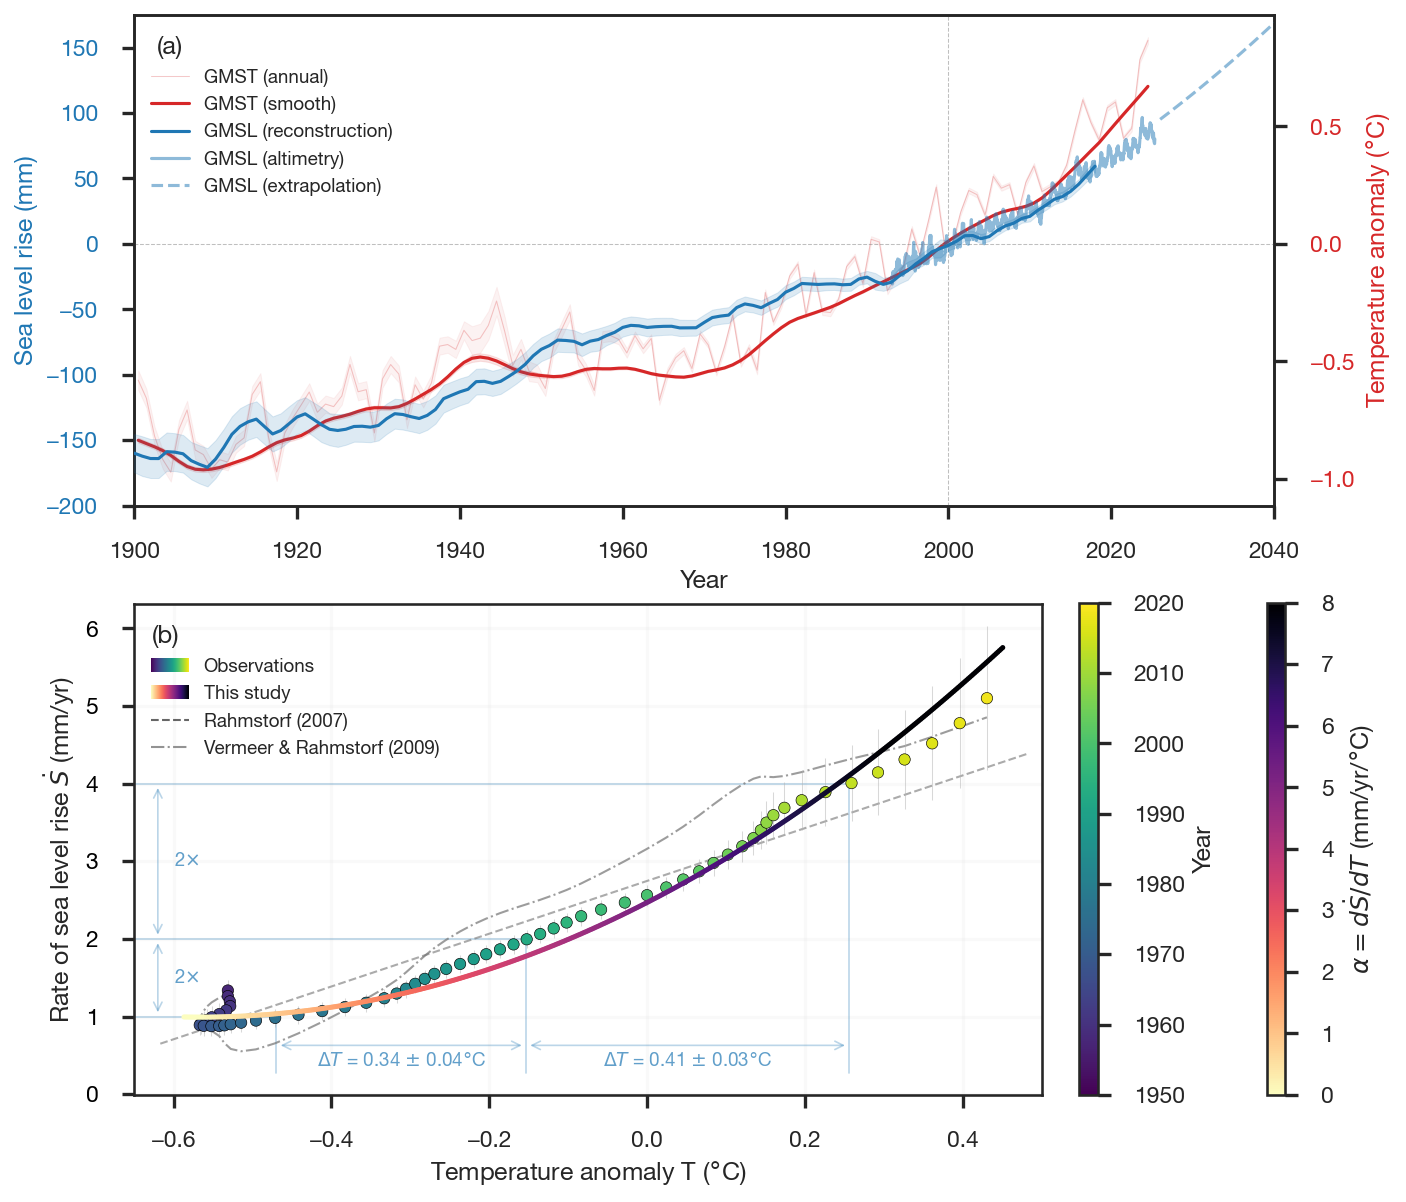

Figure 1v2 saved.


In [108]:
# ==================================================================
# Figure 1v2: Observations — GMSL, GMSL rate + GMST
# ==================================================================
# Two-panel figure: (a) = Panel A from Figure 1, (b) = Panel C from Figure 1.
# Inherits all data from the Figure 1 cell.

# ── Font sizes (adjust here) ──
FS_XLABEL  = 12
FS_YLABEL  = FS_XLABEL
FS_XTICK   = 11
FS_YTICK   = FS_XTICK
FS_LEGEND  = 9
FS_PANEL   = FS_XLABEL  # (a), (b), (c) labels
FS_CBARLABEL = FS_YLABEL  # colorbar axis label
FS_CBARTICK  = FS_YTICK   # colorbar tick labels

fig2 = plt.figure(figsize=(10, 8))
gs2 = gridspec.GridSpec(2, 1, height_ratios=[1, 1], hspace=HSPACE_BC,
                        left=0.12, right=0.88, top=0.96, bottom=0.06)

# ------------------------------------------------------------------
# Panel A: GMSL level + GMST (identical to Figure 1 Panel A)
# ------------------------------------------------------------------
ax_sl2 = fig2.add_subplot(gs2[0])
ax_T2 = ax_sl2.twinx()
ax_sl2.set_zorder(ax_T2.get_zorder() + 1)
ax_sl2.set_facecolor('none')

# Annual GMST
ax_T2.plot(yrs_ann, temp_ann, color='tab:red', lw=0.5, alpha=0.25, zorder=1,
           label='GMST (annual)')
ax_T2.fill_between(yrs_ann,
                   temp_ann - Z_90 * temp_sigma_ann,
                   temp_ann + Z_90 * temp_sigma_ann,
                   color='tab:red', alpha=0.06, zorder=1)

# GMST LOWESS smooth
ax_T2.plot(yrs_sm, temp_sm, color='tab:red', lw=1.5, zorder=2,
           label='GMST (smooth)')
ax_T2.fill_between(yrs_sm,
                   temp_sm - Z_90 * temp_sm_sig,
                   temp_sm + Z_90 * temp_sm_sig,
                   color='tab:red', alpha=0.12, zorder=2)

# Frederikse thermodynamic GMSL
mask_smooth = mask_1900 & np.isfinite(thermo_smooth)
ax_sl2.plot(fred_time[mask_smooth], thermo_smooth[mask_smooth] * M_TO_MM,
            color='tab:blue', lw=1.5, zorder=3, label='GMSL (reconstruction)')
ax_sl2.fill_between(fred_time[mask_smooth],
                    (thermo_smooth[mask_smooth] - Z_90 * thermo_sigma_smooth[mask_smooth]) * M_TO_MM,
                    (thermo_smooth[mask_smooth] + Z_90 * thermo_sigma_smooth[mask_smooth]) * M_TO_MM,
                    color='tab:blue', alpha=0.15, zorder=3)

# NASA altimetry
nasa_mask_plot = nasa_time <= XLIM_AB[1]
ax_sl2.plot(nasa_time[nasa_mask_plot], nasa_gmsl_rb[nasa_mask_plot] * M_TO_MM,
            color='tab:blue', lw=1.5, alpha=0.5, zorder=4, label='GMSL (altimetry)')

# Hamlington quadratic extrapolation
sq_obs_mask = (sq_time >= SAT_ERA_START) & (sq_time <= nasa_time[-1])
sq_ext_mask = sq_time > nasa_time[-1]
ax_sl2.plot(sq_time[sq_ext_mask], sq_fit_rb[sq_ext_mask] * M_TO_MM,
            '--', color='tab:blue', alpha=0.5, lw=1.5, zorder=5, label='GMSL (extrapolation)')

ax_sl2.set_xlabel('Year', fontsize=FS_XLABEL)
ax_sl2.set_ylabel('Sea level rise (mm)', fontsize=FS_YLABEL, color='tab:blue')
ax_T2.set_ylabel(r'Temperature anomaly ($\degree$C)', fontsize=FS_YLABEL, color='tab:red')
_style_ax(ax_sl2, 'tab:blue')
_style_ax(ax_T2, 'tab:red')

ax_sl2.set_ylim(*YLIM_SL)
f_zero = -YLIM_SL[0] / (YLIM_SL[1] - YLIM_SL[0])
t_lo, t_hi = ax_T2.get_ylim()
t_hi_aligned = -t_lo * (1 - f_zero) / f_zero
t_lo_aligned = -t_hi * f_zero / (1 - f_zero)
if t_hi_aligned >= t_hi:
    ax_T2.set_ylim(t_lo, t_hi_aligned)
else:
    ax_T2.set_ylim(t_lo_aligned, t_hi)

from matplotlib.ticker import MultipleLocator
ax_T2.yaxis.set_major_locator(MultipleLocator(0.5))

ax_sl2.axhline(0, color='gray', ls='--', lw=0.5, alpha=0.5)
ax_sl2.axvline(BASELINE_YEAR, color='gray', ls='--', lw=0.5, alpha=0.5)

h1, l1 = ax_sl2.get_legend_handles_labels()
h2, l2 = ax_T2.get_legend_handles_labels()
h_a, l_a = _reorder_legend(h1 + h2, l1 + l2, LEG_ORDER_A)
_leg_kw_a2 = dict(loc='upper left', fontsize=FS_LEGEND, framealpha=0.9)
if LEG_BBOX_A is not None:
    _leg_kw_a2['bbox_to_anchor'] = LEG_BBOX_A
ax_sl2.legend(h_a, l_a, **_leg_kw_a2)
ax_sl2.set_xlim(*XLIM_AB)
ax_sl2.text(0.02, 0.92, '(a)', transform=ax_sl2.transAxes, fontweight='bold', fontsize=FS_PANEL)

# ------------------------------------------------------------------
# Panel B: Scatter — GMSL rate vs GMST (identical to Figure 1 Panel C)
# ------------------------------------------------------------------
# Panel B axes: narrower than Panel A; colorbars positioned via bbox
PANELB_RIGHT = 0.725   # right edge of scatter axes (fraction of figure width)
gs2_bottom = gs2[1].subgridspec(1, 1)
ax_sc2 = fig2.add_subplot(gs2_bottom[0, 0])
ax_sc2.set_position([ax_sc2.get_position().x0, ax_sc2.get_position().y0,
                     PANELB_RIGHT - ax_sc2.get_position().x0,
                     ax_sc2.get_position().height])
# Colorbar bbox: [left, bottom, width, height] in figure coordinates
CBAR1_BBOX_V2 = [0.75, 0.06, 0.0125, 0.41]   # Year
CBAR2_BBOX_V2 = [0.875, 0.06, 0.0125, 0.41]   # alpha
_cax1_2 = fig2.add_axes(CBAR1_BBOX_V2)
_cax2_2 = fig2.add_axes(CBAR2_BBOX_V2)

# 90% CI error bars on observed rates
ax_sc2.errorbar(sc_T, sc_rate, yerr=Z_90 * sc_rate_se,
                fmt='none', ecolor='0.7', elinewidth=0.5, capsize=0, zorder=4, alpha=0.5)

sc_obs2 = ax_sc2.scatter(sc_T, sc_rate, c=sc_time, cmap='viridis',
                          vmin=1950, vmax=2020,
                          s=30, zorder=5, edgecolors='k', linewidths=0.3)
cb1_2 = plt.colorbar(sc_obs2, cax=_cax1_2)
cb1_2.set_label('Year', fontsize=FS_CBARLABEL)
cb1_2.ax.yaxis.set_tick_params(labelsize=FS_CBARTICK)
cb1_2.ax.xaxis.set_tick_params(labelsize=FS_CBARTICK)

# Dense rate-and-state curve
T_dense = np.linspace(sc_T.min() - 0.02, sc_T.max() + 0.02, 500)
rs_rate_dense = a_rs * T_dense**2 + b_rs * T_dense + c_rs
rs_alpha_dense = 2 * a_rs * T_dense + b_rs
sc_model2 = ax_sc2.scatter(T_dense, rs_rate_dense - 0.2, c=rs_alpha_dense, cmap='magma_r',
                            vmin=0, vmax=8,
                            s=6, marker='o', zorder=6, edgecolors='none', linewidths=0)
cb2_2 = plt.colorbar(sc_model2, cax=_cax2_2)
cb2_2.set_label(r'$\alpha = d\dot{S}/dT$ (mm/yr/$\degree$C)', fontsize=FS_CBARLABEL)
cb2_2.ax.yaxis.set_tick_params(labelsize=FS_CBARTICK)
cb2_2.ax.xaxis.set_tick_params(labelsize=FS_CBARTICK)

# Rahmstorf (2007)
a_R07 = 3.4
T_mean = np.mean(sc_T)
rate_mean = np.mean(sc_rate)
T_line = np.linspace(sc_T.min() - 0.05, sc_T.max() + 0.05, 100)
ax_sc2.plot(T_line, rate_mean + a_R07 * (T_line - T_mean),
            '--', color='0.45', lw=1., alpha=0.6)

# Vermeer & Rahmstorf (2009)
_T0_offset_5180 = berk_annual.loc[
    berk_annual['year'].between(1951, 1980), 'temp_rb'].mean()
a_VR09 = 5.6
b_VR09 = -49.0
T0_VR09 = -0.41 + _T0_offset_5180 + 0.1
dTdt_at_fred = np.interp(kin_fred_time[mask_kin_fred],
                         berk_annual['year'].values,
                         berk_annual['dTdt'].values)
vr09_rate = a_VR09 * (sc_T - T0_VR09) + b_VR09 * dTdt_at_fred
ax_sc2.plot(sc_T, vr09_rate, '-.', color='0.45', lw=1., alpha=0.7, zorder=3)

# Doubling annotations
_y_lo2 = ax_sc2.get_ylim()[0]
_VLINE_COLOR = 'tab:blue'
_VLINE_ALPHA = 0.3
ax_sc2.set_xlim(-0.65, 0.5)
_x_lo2 = ax_sc2.get_xlim()[0]
for _thresh, _T_cross in _T_at_threshold.items():
    ax_sc2.plot([_x_lo2, _T_cross], [_thresh, _thresh],
                '-', color=_VLINE_COLOR, lw=0.8, alpha=_VLINE_ALPHA, zorder=1, clip_on=True)
    ax_sc2.plot([_T_cross, _T_cross], [_y_lo2, _thresh],
                '-', color=_VLINE_COLOR, lw=0.8, alpha=_VLINE_ALPHA, zorder=1)

_y_arrow2 = _y_lo2 + 0.35
_y_label2 = _y_arrow2 - 0.08
_arrow_kw2 = dict(arrowstyle='<->', color=_VLINE_COLOR, lw=0.8, alpha=_VLINE_ALPHA)
_label_color2 = (*plt.matplotlib.colors.to_rgb(_VLINE_COLOR), 0.7)

if 1.0 in _T_at_threshold and 2.0 in _T_at_threshold:
    ax_sc2.annotate('', xy=(_T_at_threshold[2.0], _y_arrow2),
                    xytext=(_T_at_threshold[1.0], _y_arrow2),
                    arrowprops=_arrow_kw2)
    ax_sc2.text(0.5 * (_T_at_threshold[1.0] + _T_at_threshold[2.0]), _y_label2,
                f'$\\Delta T$ = {_dT1_mean:.2f} $\\pm$ {_dT1_std:.2f}$\\degree$C',
                ha='center', va='top', fontsize=FS_LEGEND, color=_label_color2)

if 2.0 in _T_at_threshold and 4.0 in _T_at_threshold:
    ax_sc2.annotate('', xy=(_T_at_threshold[4.0], _y_arrow2),
                    xytext=(_T_at_threshold[2.0], _y_arrow2),
                    arrowprops=_arrow_kw2)
    ax_sc2.text(0.5 * (_T_at_threshold[2.0] + _T_at_threshold[4.0]), _y_label2,
                f'$\\Delta T$ = {_dT2_mean:.2f} $\\pm$ {_dT2_std:.2f}$\\degree$C',
                ha='center', va='top', fontsize=FS_LEGEND, color=_label_color2)

# Vertical 2x arrows near left axis
_T_varrow2 = _x_lo2 + 0.03
if 1.0 in _T_at_threshold and 2.0 in _T_at_threshold:
    ax_sc2.annotate('', xy=(_T_varrow2, 2.0), xytext=(_T_varrow2, 1.0),
                    arrowprops=_arrow_kw2)
    ax_sc2.text(_T_varrow2 + 0.02, 1.5, r'2$\times$',
                ha='left', va='center', fontsize=FS_LEGEND, color=_label_color2)

if 2.0 in _T_at_threshold and 4.0 in _T_at_threshold:
    ax_sc2.annotate('', xy=(_T_varrow2, 4.0), xytext=(_T_varrow2, 2.0),
                    arrowprops=_arrow_kw2)
    ax_sc2.text(_T_varrow2 + 0.02, 3.0, r'2$\times$',
                ha='left', va='center', fontsize=FS_LEGEND, color=_label_color2)

ax_sc2.set_xlabel(r'Temperature anomaly T ($\degree$C)', fontsize=FS_XLABEL)
ax_sc2.set_ylabel(r'Rate of sea level rise $\dot{S}$ (mm/yr)', fontsize=FS_YLABEL)
_style_ax(ax_sc2)

# Legend
from matplotlib.lines import Line2D
from matplotlib.legend_handler import HandlerBase
from matplotlib.image import BboxImage
from matplotlib.transforms import Bbox, TransformedBbox

class _GradientHandler2(HandlerBase):
    def __init__(self, cmap, vmin, vmax):
        super().__init__()
        self.cmap = plt.get_cmap(cmap)
        self.norm = plt.Normalize(vmin, vmax)
    def create_artists(self, legend, orig_handle, xdescent, ydescent,
                       width, height, fontsize, trans):
        bb = Bbox.from_bounds(xdescent, ydescent, width, height)
        tbb = TransformedBbox(bb, trans)
        img = BboxImage(tbb, interpolation='bilinear')
        gradient = np.linspace(0, 1, 256).reshape(1, -1)
        img.set_data(self.cmap(gradient))
        return [img]

h_obs2  = Line2D([], [], label='_obs')
h_rs2   = Line2D([], [], label='_rs')
h_r07_2 = Line2D([0], [0], color='k', ls='--', lw=1., alpha=0.6)
h_vr09_2 = Line2D([0], [0], color='0.4', ls='-.', lw=1., alpha=0.7)

_handles_b2 = [h_obs2, h_rs2, h_r07_2, h_vr09_2]
_labels_b2 = LEG_ORDER_C
_handler_map2 = {
    h_obs2: _GradientHandler2('viridis', 1950, 2020),
    h_rs2:  _GradientHandler2('magma_r', 0, 8),
}
_leg_kw_b2 = dict(loc='upper left', fontsize=FS_LEGEND, framealpha=0.9,
                  handler_map=_handler_map2)
if LEG_BBOX_C is not None:
    _leg_kw_b2['bbox_to_anchor'] = LEG_BBOX_C
ax_sc2.legend(_handles_b2, _labels_b2, **_leg_kw_b2)
ax_sc2.grid(True, alpha=0.15)
ax_sc2.text(0.02, 0.92, '(b)', transform=ax_sc2.transAxes, fontweight='bold', fontsize=FS_PANEL)

plt.savefig(f'{FIG_DIR}/fig1v2_observations.png', dpi=200, bbox_inches='tight')
plt.show()
print('Figure 1v2 saved.')

In [14]:
# --- Panel C: WAIS observations vs ISMIP6 ---
# Load IMBIE WAIS observations
wais = load_component('wais')
wais_obs = wais['observations']
print(f"WAIS obs years: {wais_obs['years'][0]:.0f}–{wais_obs['years'][-1]:.0f}")
print(f"WAIS obs final value: {wais_obs['H_obs'][-1] * M_TO_MM:.1f} mm")

# Load ISMIP6 WAIS trajectories (region=1) from raw data
try:
    ismip6_wais = read_ismip6_regional(ISMIP6_BASE, region=1)
    n_runs = len(ismip6_wais)
    print(f'\nISMIP6 WAIS runs loaded: {n_runs}')

    # Collect endpoint values (at ~2020 or latest available)
    # read_ismip6_regional returns dicts with keys 'time' and 'sle_m'
    ismip6_endpoints = []
    for key, traj in ismip6_wais.items():
        years = traj['time']
        vals_mm = traj['sle_m'] * M_TO_MM  # convert m to mm SLE
        idx_2020 = np.argmin(np.abs(years - 2020))
        ismip6_endpoints.append(vals_mm[idx_2020])

    ismip6_endpoints = np.array(ismip6_endpoints)
    n_reproduce = np.sum(ismip6_endpoints >= wais_obs['H_obs'][-1] * M_TO_MM)
    n_gain_mass = np.sum(ismip6_endpoints < 0)
    print(f'  At 2020: median = {np.median(ismip6_endpoints):.1f} mm, '
          f'observed = {wais_obs["H_obs"][-1] * M_TO_MM:.1f} mm')
    print(f'  Runs reproducing observed: {n_reproduce}/{n_runs}')
    print(f'  Runs showing mass gain: {n_gain_mass}/{n_runs} '
          f'({n_gain_mass/n_runs*100:.0f}%)')
except Exception as e:
    print(f'\nCould not load ISMIP6 data: {e}')
    import traceback; traceback.print_exc()
    print('  Check ISMIP6_BASE path and read_ismip6_regional return format.')

WAIS obs years: 1992–2020
WAIS obs final value: 5.8 mm

ISMIP6 WAIS runs loaded: 77
  At 2020: median = 0.7 mm, observed = 5.8 mm
  Runs reproducing observed: 1/77
  Runs showing mass gain: 18/77 (23%)


In [15]:
# --- Semi-empirical model comparison table ---
print('=== Semi-empirical projections at 2100 (21st-century rise, SSP2-4.5) ===')
print()
print(f'{"Model":<30} {"Median (m)":>12} {"90% CI":>18}')
print('-' * 62)
print(f'{"Rahmstorf (2007)":<30} {0.67:>12.2f} {"0.63–0.71":>18}')
print(f'{"Vermeer & Rahmstorf (2009)":<30} {0.96:>12.2f} {"0.80–1.12":>18}')

rs_ssp245 = ratestate['projections_at_2100_mm']['SSP2-4.5']
rs_med = rs_ssp245['median'] / M_TO_MM
rs_p5 = rs_ssp245['p5'] / M_TO_MM
rs_p95 = rs_ssp245['p95'] / M_TO_MM
print(f'{"This study (rate-and-state)":<30} {rs_med:>12.2f} {f"{rs_p5:.2f}–{rs_p95:.2f}":>18}')
print()
print(f'Ratio to R07: {rs_med / 0.67:.1f}x')
print(f'Ratio to VR09: {rs_med / 0.96:.1f}x ({(rs_med / 0.96 - 1) * 100:.0f}% above)')

=== Semi-empirical projections at 2100 (21st-century rise, SSP2-4.5) ===

Model                            Median (m)             90% CI
--------------------------------------------------------------
Rahmstorf (2007)                       0.67          0.63–0.71
Vermeer & Rahmstorf (2009)             0.96          0.80–1.12
This study (rate-and-state)            1.30          1.04–1.56

Ratio to R07: 1.9x
Ratio to VR09: 1.4x (36% above)


In [16]:
# --- Rate-and-state projections across all SSPs ---
print('=== Rate-and-state projections at 2100 (mm) ===')
print()
for ssp in PROJ_SSPS:
    vals = ratestate['projections_at_2100_mm'][ssp]
    print(f"{ssp}: median={vals['median']:.0f} mm [{vals['p5']:.0f}–{vals['p95']:.0f}]")

=== Rate-and-state projections at 2100 (mm) ===

SSP1-2.6: median=780 mm [650–906]
SSP2-4.5: median=1304 mm [1044–1557]
SSP3-7.0: median=1999 mm [1558–2420]
SSP5-8.5: median=2772 mm [2129–3388]


---
## §4 Figure 3 — Per-component projections vs IPCC

Individual sea-level contributors showing our projections overlaid with IPCC AR6 medians and observations.

In [17]:
# --- Per-component summary table at 2100 ---
ALL_COMPONENTS = ['ocean', 'glacier', 'greenland', 'apeninsula', 'wais', 'eais']

print('=== Per-component projections at 2100 (mm, SSP2-4.5) ===')
print(f'{"Component":<15} {"Median":>8} {"P5":>8} {"P95":>8} {"In forecast?":>14}')
print('-' * 55)

for comp in ALL_COMPONENTS:
    data = all_proj[comp]['SSP2-4.5']
    samples = data['samples'][:, i2100]
    med = np.median(samples) * M_TO_MM
    p5 = np.percentile(samples, 5) * M_TO_MM
    p95 = np.percentile(samples, 95) * M_TO_MM
    in_forecast = 'Yes' if comp in FORECAST_COMPONENTS else 'No'
    print(f'{comp:<15} {med:8.0f} {p5:8.0f} {p95:8.0f} {in_forecast:>14}')

=== Per-component projections at 2100 (mm, SSP2-4.5) ===
Component         Median       P5      P95   In forecast?
-------------------------------------------------------
ocean                237      199      283            Yes
glacier              129      120      136            Yes
greenland            147       99      191            Yes
apeninsula             9        4       15            Yes
wais                 411       68     1560            Yes
eais                 -19      -29       -9             No


In [18]:
# --- Key component parameters ---
print('=== Key fitted parameters ===')
print()

# Glacier sensitivity
glacier = load_component('glacier')
print(f"Glacier R²: {glacier['metadata'].get('r2', 'N/A')}")
print(f"Glacier model type: {glacier['metadata'].get('model_type', 'N/A')}")
print()

# Greenland
greenland = load_component('greenland')
if 'posteriors' in greenland and 'discharge' in greenland['posteriors']:
    discharge = greenland['posteriors']['discharge']
    print(f"Greenland discharge R²: {greenland['metadata'].get('r2_dyn', 'N/A')}")
print()

# WAIS
print(f"WAIS model type: {wais['metadata'].get('model_type', 'N/A')}")
print(f"WAIS rheology factor: {wais['metadata'].get('rheology_factor_median', 'N/A')}")
print(f"WAIS SSP-independent: {wais['metadata'].get('ssp_independent', 'N/A')}")

=== Key fitted parameters ===

Glacier R²: 0.9949631082792403
Glacier model type: linear_dols

Greenland discharge R²: N/A

WAIS model type: a4_deep_uncertainty
WAIS rheology factor: 1.28
WAIS SSP-independent: True


In [19]:
# TODO: Multi-panel figure showing each component's projection time series
#       with observations and IPCC comparison
#       Layout: 2x3 or 3x2 grid for ocean, glacier, greenland, wais, eais, peninsula

print('TODO: Per-component projection figure')

TODO: Per-component projection figure


In [20]:
# --- Blended vs raw component sum comparison ---
# Diagnostic: quantify the effect of rate-space blending
print('=== Blended vs raw component sum at 2100 (cm, rel. to 2000) ===')
print(f'{"SSP":<12} {"Blended":>10} {"Raw sum":>10} {"Diff":>8}')
print('-' * 42)

for ssp in PROJ_SSPS:
    # Blended
    s_bl = blended[ssp]['samples'][:, i2100_b]
    med_bl = np.median(s_bl) * M_TO_CM
    
    # Raw component sum
    total_raw = np.zeros(N_SAMPLES)
    for comp in FORECAST_COMPONENTS:
        total_raw += all_proj[comp][ssp]['samples'][:, i2100]
    med_raw = np.median(total_raw) * M_TO_CM
    
    print(f'{ssp:<12} {med_bl:10.0f} {med_raw:10.0f} {med_bl - med_raw:8.1f}')

print()
print('Blended includes TWS and rate-space blending with satellite quadratic.')

=== Blended vs raw component sum at 2100 (cm, rel. to 2000) ===
SSP             Blended    Raw sum     Diff
------------------------------------------
SSP1-2.6             78         76      1.9
SSP2-4.5             95         94      0.9
SSP3-7.0            115        113      1.7
SSP5-8.5            134        134      0.2

Blended includes TWS and rate-space blending with satellite quadratic.


In [21]:
# TODO: Total GMSL forecast figure
#       - NASA altimetry observations (black)
#       - Blended forecasts per SSP (colored, 66% and 90% CI shading)
#       - Satellite quadratic extrapolation (grey dashed)
#       - IPCC AR6 medians (dashed colored)

print('TODO: Total GMSL forecast figure')

TODO: Total GMSL forecast figure


In [22]:
# --- Exceedance thresholds (blended forecast) ---
print('=== Exceedance thresholds at 2100 (rel. to pre-industrial, blended) ===')
print()

thresholds_m = [0.5, 1.0, 1.5, 2.0]
print(f'{"SSP":<12}', '  '.join([f'P(>{t:.1f}m)' for t in thresholds_m]))
print('-' * 60)

for ssp in POLICY_SSPS:
    s = blended[ssp]['samples'][:, i2100_b]
    s_pi = s + PREINDUSTRIAL_OFFSET_M
    
    probs = [np.mean(s_pi > t) * 100 for t in thresholds_m]
    print(f'{ssp:<12}', '  '.join([f'{p:7.1f}%' for p in probs]))

# Cross-check against headline stats
print()
print('Headline stats:')
for ssp in POLICY_SSPS:
    hs = headline['scenarios'][ssp]['2100']
    probs = [hs[f'P_exceed_{t:.1f}m_preindustrial'] for t in thresholds_m]
    print(f'  {ssp:<12}', '  '.join([f'{p:7.1f}%' for p in probs]))

=== Exceedance thresholds at 2100 (rel. to pre-industrial, blended) ===

SSP          P(>0.5m)  P(>1.0m)  P(>1.5m)  P(>2.0m)
------------------------------------------------------------
SSP1-2.6       100.0%     46.3%     17.1%      6.2%
SSP2-4.5       100.0%     73.5%     22.9%      9.5%
SSP3-7.0       100.0%     94.5%     34.3%     13.9%

Headline stats:
  SSP1-2.6       100.0%     46.3%     17.1%      6.2%
  SSP2-4.5       100.0%     73.5%     22.9%      9.5%
  SSP3-7.0       100.0%     94.5%     34.3%     13.9%


---
## §7 Budget closure diagnostics

Component sum vs NASA altimetry over the satellite era (1993–2020). Residual attribution across components.

In [23]:
# --- Budget closure ---
# TODO: Compute component sum over satellite era and compare to NASA altimetry.
#       This requires hindcast values (observations) from each component,
#       not the MC projection samples.
#       Values from manuscript:
#         Residual rate: 0.37 mm/yr
#         Thermosteric absorbs: 57%
#         TWS absorbs: 23%
#         All ice components within 1.5 sigma

print('TODO: Budget closure diagnostic')
print()
print('Manuscript values:')
print('  Residual rate trend: 0.37 mm/yr')
print('  Thermosteric share: 57%')
print('  TWS share: 23%')
print('  All ice components within 1.5σ')

TODO: Budget closure diagnostic

Manuscript values:
  Residual rate trend: 0.37 mm/yr
  Thermosteric share: 57%
  TWS share: 23%
  All ice components within 1.5σ


---
## §8 Supplementary tables & figures

In [24]:
# --- Table S1: Observational datasets ---
# TODO: Generate table of calibration datasets, time spans, and sources
#       Read from component metadata

print('=== Table S1: Calibration datasets ===')
print(f'{"Component":<15} {"Type":<30} {"Obs years":<20}')
print('-' * 65)

for comp_name in ALL_COMPONENTS:
    comp = load_component(comp_name)
    mtype = comp['metadata'].get('model_type', 'N/A')
    obs = comp.get('observations', {})
    
    # Handle different obs structures
    if 'years' in obs:
        yr_range = f"{obs['years'][0]:.0f}–{obs['years'][-1]:.0f}"
    elif 'smb' in obs:  # Greenland has sub-components
        smb_yrs = obs['smb']['years']
        dyn_yrs = obs['discharge']['years']
        yr_range = f"SMB: {smb_yrs[0]:.0f}–{smb_yrs[-1]:.0f}, D: {dyn_yrs[0]:.0f}–{dyn_yrs[-1]:.0f}"
    else:
        yr_range = 'N/A'
    
    print(f'{comp_name:<15} {mtype:<30} {yr_range:<20}')

=== Table S1: Calibration datasets ===
Component       Type                           Obs years           
-----------------------------------------------------------------
ocean           twolayer_noaa                  1956–2026           
glacier         linear_dols                    2000–2024           
greenland       smb_literature_plus_discharge_delay SMB: 1972–2018, D: 1972–2018
apeninsula      linear_dols                    1992–2020           
wais            a4_deep_uncertainty            1992–2020           
eais            trend_only                     1992–2020           


---
## Gaps & TODOs

**Resolved:**
1. ~~Blended forecast samples~~ — Export cell added to `component_forecast.ipynb`; loaded from `component_results.h5` `blended/` group.
2. ~~IPCC medians~~ — Now read from IPCC AR6 NetCDF files via `read_ipcc_component_nc()`.
3. ~~Pre-industrial offset~~ — Computed from Frederikse reconstruction (GMSL at 2000 minus 1850–1900 mean).
4. ~~ISMIP6 trajectories~~ — Loaded from raw data via `read_ismip6_regional(region=1)`.
5. ~~Rate-and-state posterior~~ — Export cell added to `bayesian_ratestate.ipynb`; posterior samples, rate curve, and sensitivity curve saved to `bayesian_ratestate_posterior.h5`.
7. ~~Sensitivity evolution~~ — Saved as part of gap 5: equilibrium sensitivity curve with full posterior uncertainty, plus record-averaged sensitivity for Rahmstorf comparison.

**Remaining:**
6. **Budget closure computation** — TODO: The budget closure diagnostics (residual rate, per-component attribution) need careful review before implementing here. The calculation is in `component_summation.ipynb` cells 9 and 21, but the methodology is under active discussion. Defer until the approach is finalized.

**Before submission:**
- Run `component_forecast.ipynb` to populate `blended/` group in `component_results.h5`
- Run `bayesian_ratestate.ipynb` to populate `bayesian_ratestate_posterior.h5`
- Then run this notebook end-to-end to verify all numbers match the manuscript

---
## Remaining TODOs

1. **Budget closure computation** -- The budget closure diagnostics (residual rate, per-component attribution) need careful review before implementing here. The calculation is in `component_summation.ipynb` cells 9 and 21, but the methodology is under active discussion. Defer until the approach is finalized.
2. **Figures** -- Per-component projection figure (cell 21), total GMSL forecast figure (cell 24), exceedance curve plot (cell 25) are stubs.
3. **Manuscript text vs headline stats** -- The manuscript text (lines 105-107) reports values 1-3 cm / 1-3% below the current `manuscript_headline_stats.json`. Either the manuscript needs updating or the headline stats were regenerated after the last manuscript edit. Reconcile before submission.

**Before submission:**
- Run `component_forecast.ipynb` to populate `blended/` group in `component_results.h5`
- Run `bayesian_ratestate.ipynb` to populate `bayesian_ratestate_posterior.h5`
- Then run this notebook end-to-end to verify all numbers match the manuscript